# LLM Inference Optimization -- Comprehensive Guide

## Table of Contents

### Part I: Foundations
1. [Challenges in LLM Inference](#challenges)
2. [KV Caching](#kv-caching)
3. [Multi-Query Attention (MQA) vs Grouped-Query Attention (GQA)](#mqa-gqa)

### Part II: 16 Inference Optimization Techniques
4. [Technique 1 -- Streaming Generation](#t1-streaming)
5. [Technique 2 -- Token Parallelism](#t2-token-parallelism)
6. [Technique 3 -- Prefetch Pipelines](#t3-prefetch)
7. [Technique 4 -- CUDA Graphs](#t4-cuda-graphs)
8. [Technique 5 -- Speculative Decoding](#t5-speculative)
9. [Technique 6 -- PagedAttention](#t6-paged-attention)
10. [Technique 7 -- KV Cache Quantization](#t7-kv-quant)
11. [Technique 8 -- Dynamic Batching](#t8-dynamic-batching)
12. [Technique 9 -- FP8 Kernels](#t9-fp8)
13. [Technique 10 -- Asynchronous Prefill (Chunked Prefill / Disaggregated Serving)](#t10-async-prefill)
14. [Technique 11 -- Memory Offload](#t11-memory-offload)
15. [Technique 12 -- Early Exit Heads](#t12-early-exit)
16. [Technique 13 -- Context Window Streaming](#t13-context-streaming)
17. [Technique 14 -- GPU-CPU Overlap](#t14-gpu-cpu-overlap)
18. [Technique 15 -- Continuous Batching (Iteration-Level Scheduling)](#t15-continuous-batching)
19. [Technique 16 -- Request Coalescing](#t16-request-coalescing)

### Part III: Summary and Comparisons
20. [Master Comparison Table](#master-table)
21. [Anatomy of an LLM Inference Request](#anatomy)
22. [Inference Frameworks Comparison](#frameworks)
23. [Memory Estimation Formulas](#memory-formulas)
24. [Decoding Strategies](#decoding-strategies)

### Part IV: Interview Preparation
25. [Top 20 LLM Inference Interview Q&A](#interview-qa)

### Part V: References
26. [References](#references)

# **Optimizing LLM Inference: Challenges and Cutting-Edge Techniques**


## **Challenges in LLM Inference**

### 🚧 **1. Autoregressive Nature (Sequential Bottleneck)**

Most LLMs follow an **autoregressive** approach, meaning they generate text one token at a time. This imposes a strict sequential constraint—each token depends on the previous ones, limiting parallelism.

🔹 **Why is this a problem?**  
Even with powerful hardware, generating long outputs remains slow because tokens cannot be computed in parallel.

### 🚀 **2. Quadratic Scaling with Input Length**

LLMs use self-attention mechanisms that scale **quadratically** with input length. If the input grows from 1,000 to 2,000 tokens, the compute requirement **quadruples** instead of doubling.

🔹 **Why is this a problem?**  
Handling long documents or conversations becomes expensive and slow due to excessive compute demands.

----------

## **Techniques to Optimize LLM Inference**

Researchers and engineers have developed several optimization techniques to overcome these challenges. Let’s explore some of the most effective ones.

### **1️⃣ Reduce Compute Costs**

🔹 **Key Techniques:**

-   **KV Caching**: Stores past key-value pairs to avoid redundant computations during inference.
-   **Knowledge Distillation**: A smaller model (student) learns from a large model (teacher) to mimic its behavior with fewer computations.
-   **Early Exit Mechanisms**: Dynamically stops computation in earlier layers when confident predictions are reached.

👉 **Real-world impact:** KV caching alone can significantly reduce the compute required per token, especially in chat-based applications.

----------

### **2️⃣ Speed Up Decoding**

Since autoregressive models generate tokens sequentially, speeding up decoding improves throughput.

🔹 **Key Techniques:**

-   **Parallel Decoding**: Uses multiple hypotheses to generate tokens in parallel.
-   **Speculative Decoding**: A smaller model first predicts a batch of tokens, and the larger model verifies them in one step.

👉 **Real-world impact:** Speculative decoding can **double or triple** token generation speed without compromising quality.

----------

### **3️⃣ Reduce Storage Needs**

LLMs require vast storage for weights and activations, making deployment expensive.

🔹 **Key Techniques:**

-   **Quantization**: Reduces precision (e.g., from 32-bit to 16-bit, 8-bit, or even 4-bit), lowering storage and memory bandwidth requirements.
-   **Sparse Models**: Prune unnecessary connections in the model, reducing size without a significant accuracy drop.

👉 **Real-world impact:** Quantization enables running LLMs on edge devices with minimal performance loss.

Here's an interactive explanation guide for **K-V Caching in LLMs** to help you understand the concept step by step.

----------

## **Understanding K-V Caching in LLMs**

### **1️⃣ Why is Caching Needed?**

-   Large Language Models (LLMs) do **not** have session memory.
-   Every request **repeats** previous conversation history.
-   This **increases computation** and slows down inference.

### **2️⃣ What is K-V Caching?**

-   **K-V Cache** refers to storing **Keys (K) and Values (V)** from the **self-attention layers** of a Transformer model.
-   This cache allows reuse of computations instead of **recalculating everything** for every request.

### **3️⃣ Where is it Useful?**

-   **Repetitive prompts:** If your query has a long instruction set (e.g., sentiment analysis guide), caching avoids recomputing instructions.
-   **Question-answering systems:** If an AI assistant frequently refers to a **product manual**, caching ensures it’s **not reprocessed** each time.
-   **Few-shot learning:** Caching lets you include **many examples** without increasing cost drastically.

### **4️⃣ How Does It Work?**

1.  **Model processes the input** → Generates **K-V pairs** in the attention layers.
2.  **Cache stores these K-V pairs** → Avoids re-computation in future requests.
3.  **For new inputs**, cached K-V values are reused instead of being recalculated.

### **5️⃣ Example: Claude API with Context Caching**

Here’s how caching works in **Claude**:

```json
{
 "model": "claude-3-5-sonnet",
 "max_tokens": 1024,
 "system": [
   {
     "type": "text",
     "text": "<System Prompt>"
   },
   {
     "type": "text",
     "text": "<Product Manual>",
     "cache_control": {"type": "ephemeral"}
   }
 ],
 "messages": [
   {
     "role": "user",
     "content": "Which battery should I use?"
   }
 ]
}

```

### **6️⃣ Trade-offs of Caching**

✅ **Pros:**  
✔️ **Speeds up inference**  
✔️ **Reduces cost** (cached tokens billed once)  
✔️ **Allows longer prompts** (few-shot learning)

⚠️ **Cons:**  
❌ **Consumes storage** (K-V caches can be large)  
❌ **Limited caching duration** (e.g., Claude’s cache lasts **5 minutes**)

##### Efficient KV Cache Implementations
- `FlashAttention`: Reduces memory bandwidth requirements while maintaining attention fidelity.
- `Paged KV Cache`: Inspired by memory paging systems, it dynamically manages K, V entries without sacrificing performance.
- `Sparse Attention Mechanisms`: Prunes redundant K, V entries adaptively, improving efficiency for long-context models.

### **7️⃣ Best Practices**

✔️ **Place reusable content at the start** (prompt prefix)  
✔️ **Use caching for instruction-heavy tasks**  
✔️ **Monitor cache size to balance cost and performance**




## 🔍 Multi-Query Attention (MQA) vs Grouped-Query Attention (GQA)
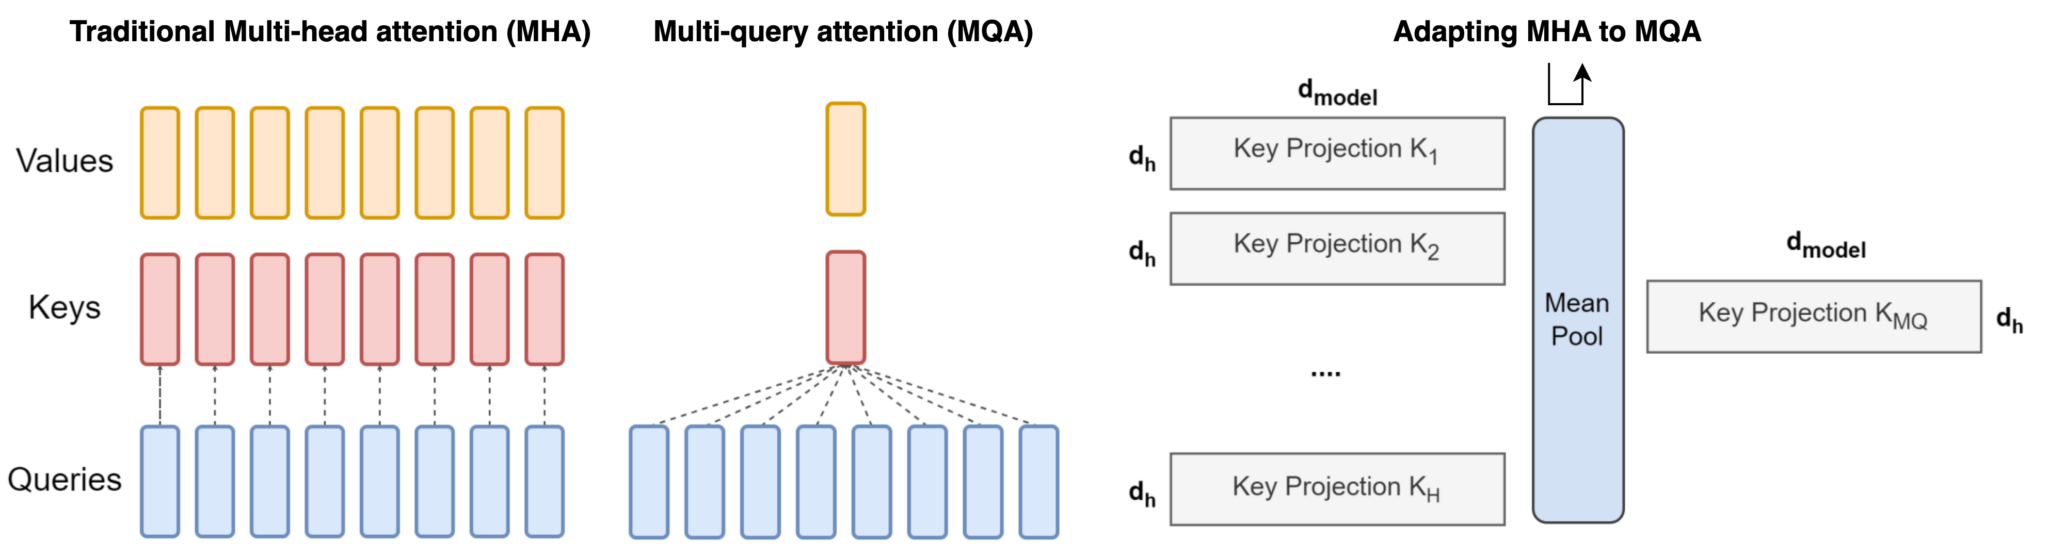
### 🚀 **Motivation: Why Move Beyond Multi-Head Attention (MHA)?**

Traditional **Multi-Head Attention (MHA)** provides high representational power by using separate projection matrices for **queries, keys, and values** per head. However, this becomes **computationally expensive** at inference time for large LLMs due to the growing number of key-value heads — resulting in **memory bottlenecks** and **latency issues**.

---

### 🔄 **1. Multi-Query Attention (MQA)**

#### ✅ **Definition:**
MQA uses multiple **query heads** but only **a single shared key and value head** across all attention heads.

#### 🎯 **Why it Emerged:**
To significantly reduce **memory bandwidth** and **latency**, especially in **decoder-only models** used in generation.

---

### 🧪 **Emergence of MQA:**

> MQA emerged as a practical solution to address memory bottlenecks during inference. By simplifying the attention mechanism — multiple queries, but just **one shared key and value head** — it reduces memory traffic and computation load.

- Used in large models: **PaLM, StarCoder, Falcon**
- Especially effective in **auto-regressive decoding**

#### 🧠 **How it works:**
- Compute Q as usual for each head.
- **Mean-pool K and V projection weights** from all heads → shared K and V across heads.
- **Replicate** the single shared K and V for each query head during computation.

---

### 🔧 **How to Convert MHA to MQA (Source: [arXiv:2305.13245](https://arxiv.org/pdf/2305.13245.pdf)):**

#### 🧱 Step 1: **Checkpoint Conversion**
- Average (mean-pool) the **key** and **value** projection matrices across heads:
  ```text
  W_K_mqa = mean(W_K_head1, ..., W_K_headH)
  W_V_mqa = mean(W_V_head1, ..., W_V_headH)
  ```
- Retain individual query projections.

#### 🔁 Step 2: **Post-Conversion Pre-training**
- Apply **further training** for a small fraction (α) of original steps.
- Allows the model to **adjust to the simplified attention structure**.

#### ⚠️ Trade-Off:
- While inference is fast, **some quality degradation** and **training instability** may occur due to reduced capacity in K and V representations.

> ✅ *Summary (One-Liner for Interview):*  
> MQA improves inference efficiency by sharing keys and values across all heads, trading off some quality for massive speed gains.

> 🧠 *Takeaway:*  
> It's **ideal for decoding at scale** and deployment, but might need careful tuning and re-training.

---

### 🧱 **2. Grouped-Query Attention (GQA)**
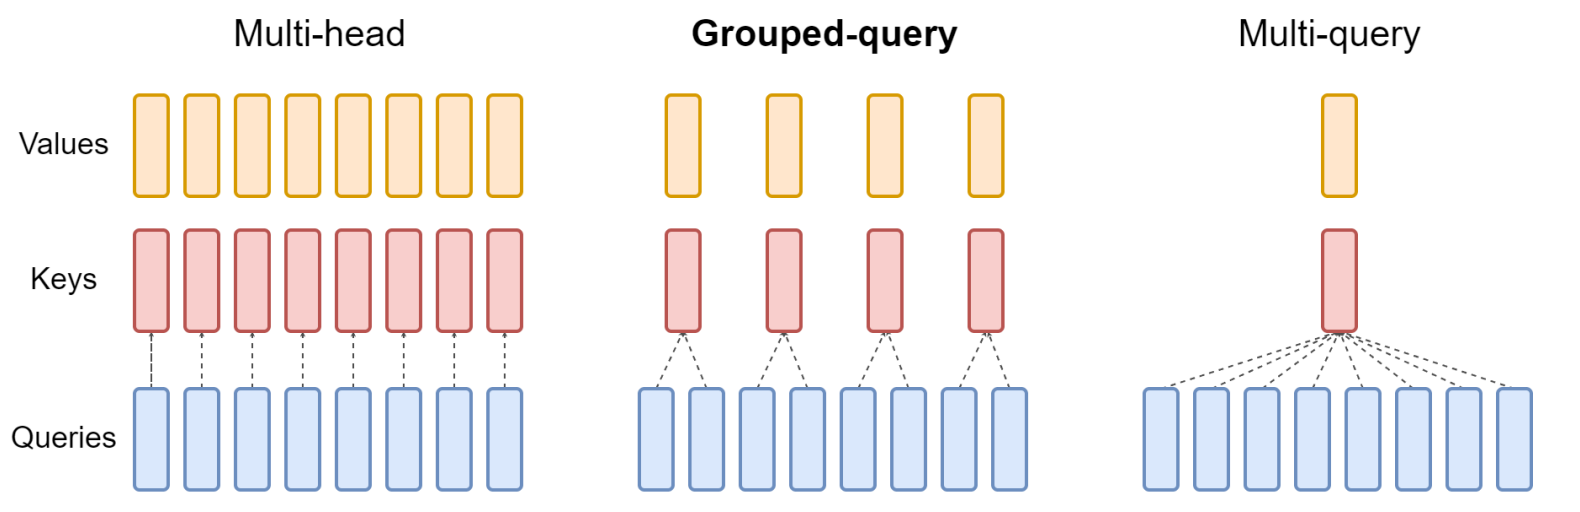
#### ✅ **Definition:**
GQA is a hybrid between **MHA** and **MQA**. It **divides query heads into groups**, where each group **shares** a key and value projection.

#### 🧠 **How it works:**
- Say you have **H = 12 heads** and **G = 4 groups**.
- Each group of 3 heads shares the same K and V matrices.
- More flexible than MQA, and more efficient than MHA.

#### 🔄 **Converting MHA to GQA:**
- **Mean-pool K and V** matrices **within each group** to create shared projections.

---

### 🔄 **Special Cases:**
| GQA-G | Meaning                                      |
|--------|-----------------------------------------------|
| **G = 1** | Equivalent to **MQA** (all heads share one K/V) |
| **G = H** | Equivalent to **MHA** (no sharing)         |

---

### 📊 **Trade-off in GQA:**
- **More groups (G ↑)** → Closer to MHA → Better quality, slower inference
- **Fewer groups (G ↓)** → Closer to MQA → Faster, may lose precision

> ✅ *Summary (One-Liner for Interview):*  
> GQA balances MHA’s expressiveness and MQA’s efficiency by grouping query heads to share key-value pairs.

> 🧠 *Takeaway:*  
> GQA is **scalable**, **configurable**, and offers a smoother performance–quality trade-off than MQA.

---

### 📷 **Diagram Source (Optional)**:
From the paper ["Efficient Inference with Multi-Query Attention"](https://arxiv.org/pdf/2305.13245.pdf):

| Left → MHA | Middle → MQA | Right → MHA → MQA conversion (mean-pooling) |

---

### ✅ TL;DR Comparison Table

| Feature         | MHA                          | MQA                            | GQA (G = 4 as example)              |
|-----------------|-------------------------------|----------------------------------|-------------------------------------|
| Query Heads     | Separate for each head         | Separate                        | Separate                            |
| Key/Value Heads | Separate per head              | **Shared across all heads**     | **Shared within each group**        |
| Memory Load     | High                           | Very Low                        | Moderate                            |
| Speed           | Slowest                        | Fastest                         | Balanced                            |
| Expressiveness  | Best                           | Reduced                         | Nearly as good as MHA               |
| Use Case        | Training phase, small models   | Inference, decoder-only models | Both training & inference           |

-

<a id="t1-streaming"></a>
# Part II: 16 Inference Optimization Techniques

---

## Technique 1: Streaming Generation

### Definition and Intuition
Streaming generation delivers tokens to the client **one at a time** (or in small chunks) as they are produced, rather than waiting for the entire response to be generated. This uses protocols like **Server-Sent Events (SSE)** or **WebSockets** to push tokens incrementally. The key insight is that perceived latency (Time-To-First-Token, TTFT) matters more to users than total generation time.

### How It Works (ASCII Diagram)
```
WITHOUT STREAMING:
  Client ----request----> Server
  Client                  Server [generates t1, t2, t3, ... t100]
  Client <--full response-- Server    (user waits for ALL tokens)
  |<------- long wait -------->|

WITH STREAMING (SSE):
  Client ----request----> Server
  Client <----t1--------- Server     (user sees first token immediately)
  Client <----t2--------- Server
  Client <----t3--------- Server
  Client <----t4--------- Server
  ...                     ...
  Client <----t100------- Server
  |<-TTFT->|                         (perceived latency = TTFT only)

SSE Protocol:
  data: {"token": "Hello"}
  data: {"token": " world"}
  data: {"token": "!"}
  data: [DONE]
```

### Practical Impact
| Metric | Without Streaming | With Streaming |
|--------|------------------|----------------|
| **Time-To-First-Token** | = Total generation time | ~50-200ms (prefill time only) |
| **Perceived latency** | Very high for long outputs | Very low |
| **Total generation time** | Same | Same (+ minor SSE overhead) |
| **User experience** | Poor for long responses | Excellent -- feels responsive |

### When to Use / When NOT to Use
- **Use when:** Building chat interfaces, interactive applications, any user-facing generation
- **Use when:** Response length is unpredictable or potentially long
- **Do NOT use when:** You need to post-process the entire response before showing it (e.g., JSON validation, safety filtering on complete output)
- **Do NOT use when:** Downstream system needs complete response (batch pipelines, API-to-API calls)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **OpenAI API** | `stream=True` parameter |
| **vLLM** | Built-in SSE streaming |
| **HuggingFace TGI** | SSE streaming by default |
| **Ollama** | Streaming by default |
| **LangChain** | `.stream()` and `.astream()` methods |

> **Interview One-Liner:** Streaming generation reduces perceived latency by delivering tokens incrementally via SSE/WebSocket, so users see the first token in milliseconds rather than waiting for the full response.

<a id="t2-token-parallelism"></a>
## Technique 2: Token Parallelism

### Definition and Intuition
Token parallelism processes tokens from **multiple requests simultaneously** on a single GPU by batching them together. Unlike data parallelism (which splits work across GPUs), token parallelism exploits the fact that GPU tensor cores can process multiple sequences' tokens in the same matrix multiplication. The key insight is that a single token's forward pass underutilizes the GPU -- batching multiple sequences' tokens together saturates the compute units.

### How It Works (ASCII Diagram)
```
WITHOUT TOKEN PARALLELISM (Sequential):
  Time -->
  GPU: [Req1:t5] [idle] [Req2:t3] [idle] [Req3:t7] [idle]
  Utilization: ~15-30%

WITH TOKEN PARALLELISM (Batched):
  Time -->
  GPU: [Req1:t5 | Req2:t3 | Req3:t7]  [Req1:t6 | Req2:t4 | Req3:t8]
  Utilization: ~70-90%

Matrix Multiplication Batching:
  Single request:    Q(1, d) x K(d, seq_len)   -> underutilized tensor cores
  Batched requests:  Q(B, d) x K(d, seq_len)   -> tensor cores fully utilized

  where B = number of concurrent sequences
```

### Practical Impact
| Metric | Single Request | Token Parallel (batch=32) |
|--------|---------------|--------------------------|
| **GPU Utilization** | 15-30% | 70-90% |
| **Throughput** | Baseline | 5-15x improvement |
| **Per-request latency** | Baseline | Slight increase (~10-20%) |
| **Cost per token** | High | Much lower |

### When to Use / When NOT to Use
- **Use when:** Serving multiple concurrent users, high-throughput inference
- **Use when:** GPU utilization is low on single-request serving
- **Do NOT use when:** Ultra-low latency for a single user is the priority (adds slight latency)
- **Do NOT use when:** Requests have vastly different sequence lengths (padding waste)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | Automatic token-level batching |
| **TensorRT-LLM** | In-flight batching |
| **TGI** | Token-level scheduling |
| **DeepSpeed-MII** | Dynamic token batching |

> **Interview One-Liner:** Token parallelism batches tokens from multiple requests into a single GPU matrix multiplication, increasing utilization from ~20% to ~80% and dramatically improving throughput.

<a id="t3-prefetch"></a>
## Technique 3: Prefetch Pipelines

### Definition and Intuition
Prefetch pipelines **overlap data preparation with computation** by using double-buffering: while the GPU processes the current batch, the CPU simultaneously prepares the next batch (tokenization, padding, KV cache allocation). This hides the data preparation latency behind GPU compute time, ensuring the GPU never stalls waiting for input.

### How It Works (ASCII Diagram)
```
WITHOUT PREFETCHING (Sequential):
  CPU:  [Prepare B0]            [Prepare B1]            [Prepare B2]
  GPU:               [Compute B0]            [Compute B1]            [Compute B2]
  Time: |-----idle----|----compute----|----idle----|----compute----|

WITH PREFETCHING (Double-Buffered Pipeline):
  CPU:  [Prepare B0][Prepare B1][Prepare B2][Prepare B3]
  GPU:              [Compute B0][Compute B1][Compute B2][Compute B3]
  Time:             |--overlapped--|--overlapped--|--overlapped--|

  Pipeline Detail:
  +----------+     +----------+     +----------+
  | Buffer A | --> | GPU Exec | --> | Output   |
  +----------+     +----------+     +----------+
       ^                                 |
       |          (swap buffers)         |
       +----------+                     v
       | Buffer B | <-- CPU Prep <-- Next Batch
       +----------+

TRIPLE BUFFERING (for H2D transfer overlap):
  CPU:      [Prep B0][Prep B1][Prep B2][Prep B3]
  Transfer:         [H2D  B0][H2D  B1][H2D  B2]
  GPU:                       [Exec B0][Exec B1][Exec B2]
```

### Practical Impact
| Metric | Without Prefetch | With Prefetch |
|--------|-----------------|---------------|
| **GPU idle time** | 10-30% of total time | <2% |
| **Throughput** | Baseline | 1.2-1.5x improvement |
| **Latency per batch** | CPU_prep + GPU_compute | max(CPU_prep, GPU_compute) |
| **CPU utilization** | Bursty | Steady |

### When to Use / When NOT to Use
- **Use when:** Data preparation (tokenization, padding) takes significant time relative to GPU compute
- **Use when:** Serving with dynamic batching where batch formation has overhead
- **Do NOT use when:** GPU compute time dominates (prep time negligible)
- **Do NOT use when:** Memory is extremely tight (double-buffering uses 2x input buffer memory)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **PyTorch DataLoader** | `prefetch_factor` parameter, `num_workers` > 0 |
| **TensorRT-LLM** | Built-in prefetch pipeline |
| **NVIDIA Triton** | Dynamic batching with prefetch |
| **vLLM** | Async scheduling pipeline |

> **Interview One-Liner:** Prefetch pipelines overlap CPU data preparation with GPU computation using double/triple buffering, eliminating GPU stalls and improving throughput by 20-50%.

<a id="t4-cuda-graphs"></a>
## Technique 4: CUDA Graphs

### Definition and Intuition
CUDA Graphs capture an entire sequence of GPU operations (kernel launches, memory copies) into a **replayable graph**, which can then be launched with a **single CPU call**. Normally, each GPU kernel requires a CPU-side launch (~5-15 microseconds overhead per kernel). For LLM decode steps that run hundreds of small kernels per token, this CPU overhead becomes a bottleneck. CUDA Graphs eliminate this by recording the operation sequence once and replaying it with near-zero CPU overhead.

### How It Works (ASCII Diagram)
```
WITHOUT CUDA GRAPHS (Normal Execution):
  CPU: [Launch K1](5us) [Launch K2](5us) [Launch K3](5us) ... [Launch K100](5us)
  GPU:            [K1]            [K2]            [K3]   ...            [K100]
  
  CPU overhead per token = 100 kernels x 5us = 500us = 0.5ms
  For 100 tokens/sec target: 50ms of CPU overhead (significant!)

WITH CUDA GRAPHS (Graph Replay):
  Recording Phase (once):
    CPU: [Record K1, K2, K3, ... K100 into Graph]
    GPU: [K1][K2][K3]...[K100]   (captured, not executed)

  Replay Phase (every decode step):
    CPU: [Launch Graph](~10us total)
    GPU: [K1][K2][K3]...[K100]   (entire sequence replayed)
  
  CPU overhead per token = ~10us (vs 500us before) = 50x reduction

CONSTRAINT -- Static Shapes Required:
  +------------------+     +------------------+
  | Static Shapes    |     | Dynamic Shapes   |
  | (decode phase)   |     | (prefill phase)  |
  | batch_size=fixed  |     | seq_len=variable |
  | seq_len+=1       |     | Cannot use CUDA  |
  | CAN use CUDA     |     | Graphs easily    |
  | Graphs           |     |                  |
  +------------------+     +------------------+
```

### Practical Impact
| Metric | Without CUDA Graphs | With CUDA Graphs |
|--------|-------------------|-----------------|
| **CPU kernel launch overhead** | 0.3-1ms per decode step | ~10us per decode step |
| **Decode latency** | Higher (CPU-bound) | Lower |
| **Throughput (small batches)** | Limited by CPU | GPU-bound (ideal) |
| **Speedup** | Baseline | 1.1-1.3x for decode phase |

### When to Use / When NOT to Use
- **Use when:** Decode phase with fixed batch sizes (most common LLM serving scenario)
- **Use when:** Small batch sizes where CPU overhead is proportionally large
- **Do NOT use when:** Shapes change every iteration (variable-length prefill)
- **Do NOT use when:** Using operations that are not CUDA-graph-capturable (some custom ops, dynamic control flow)
- **Caveat:** Requires pre-allocating graphs for each expected batch size

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | Automatic CUDA graph capture for decode phase |
| **TensorRT-LLM** | Built-in CUDA graph support |
| **SGLang** | CUDA graph optimization for decode |
| **PyTorch** | `torch.cuda.CUDAGraph` API |

> **Interview One-Liner:** CUDA Graphs capture a sequence of GPU kernels as a replayable graph, eliminating per-kernel CPU launch overhead (~5us each) and reducing decode-phase latency by 10-30%.

<a id="t5-speculative"></a>
## Technique 5: Speculative Decoding (Enhanced)

### Definition and Intuition
Speculative decoding uses a **small, fast "draft" model** to generate K candidate tokens, then the **large "target" model verifies all K tokens in a single forward pass**. Since the target model's forward pass cost is roughly the same whether verifying 1 token or K tokens (due to parallel verification), you effectively generate multiple tokens per forward pass of the expensive model. The acceptance/rejection follows a modified rejection sampling scheme that guarantees the output distribution is identical to the target model.

### How It Works (ASCII Diagram)
```
STANDARD AUTOREGRESSIVE (1 token per forward pass of large model):
  Large Model: [fwd]->[t1] [fwd]->[t2] [fwd]->[t3] [fwd]->[t4] [fwd]->[t5]
  Total: 5 forward passes of large model

SPECULATIVE DECODING (K=4 draft tokens):
  Step 1: Draft model generates K=4 tokens (FAST)
    Draft Model: [fwd]->[d1] [fwd]->[d2] [fwd]->[d3] [fwd]->[d4]
    Cost: 4 x (small model fwd) ≈ negligible vs large model

  Step 2: Target model verifies all 4 in ONE forward pass
    Target Model: [single fwd pass with d1,d2,d3,d4] 
                  -> p(d1)=0.95 ACCEPT
                  -> p(d2)=0.88 ACCEPT  
                  -> p(d3)=0.92 ACCEPT
                  -> p(d4)=0.12 REJECT -> sample new t4 from adjusted dist
    Result: [d1, d2, d3, t4_new] = 4 tokens from 1 large model fwd pass!

  Overall: 4 tokens in ~1.1 large model forward passes (vs 4 normally)

VERIFICATION DETAIL:
  For each position i:
    if random() < min(1, p_target(d_i) / p_draft(d_i)):
      ACCEPT d_i, continue to i+1
    else:
      REJECT d_i, sample from adjusted distribution:
        p_adjusted(x) = max(0, p_target(x) - p_draft(x)) / Z
      STOP (don't verify remaining draft tokens)

VARIANTS:
  +-------------------+------------------------------------------+
  | Medusa            | Multiple prediction heads on target      |
  |                   | model itself (no separate draft model)   |
  +-------------------+------------------------------------------+
  | EAGLE             | Feature-level drafting using target       |
  |                   | model's hidden states                    |
  +-------------------+------------------------------------------+
  | Lookahead         | N-gram based speculation using            |
  |                   | Jacobi iteration                         |
  +-------------------+------------------------------------------+
  | Self-Speculative  | Use early layers of target model as      |
  |                   | the draft model (layer skipping)         |
  +-------------------+------------------------------------------+
```

### Practical Impact
| Metric | Standard Decoding | Speculative (K=5, 80% accept) |
|--------|------------------|-------------------------------|
| **Tokens per large-model fwd pass** | 1 | ~3-4 (average) |
| **Speedup** | 1x | 2-3x |
| **Quality** | Baseline | **Identical** (provably same distribution) |
| **Memory overhead** | Baseline | + draft model size (1-7B typically) |
| **Acceptance rate** | N/A | 70-90% (depends on draft/target similarity) |

### When to Use / When NOT to Use
- **Use when:** Target model is large (>30B params) and latency-sensitive
- **Use when:** A good draft model exists (same tokenizer, similar domain)
- **Use when:** Batch size is small (single-user latency optimization)
- **Do NOT use when:** Already compute-bound (large batches saturating GPU)
- **Do NOT use when:** No suitable draft model available
- **Do NOT use when:** Draft-target distribution mismatch is high (low acceptance rate negates benefit)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | `--speculative-model` flag, supports Medusa/EAGLE |
| **TensorRT-LLM** | Speculative decoding with draft model |
| **HuggingFace** | `assisted_generation` in `transformers` |
| **SGLang** | EAGLE-based speculative decoding |
| **llama.cpp** | `--draft` model flag |

> **Interview One-Liner:** Speculative decoding uses a cheap draft model to propose K tokens that the expensive target model verifies in one forward pass, achieving 2-3x speedup with mathematically identical output distribution.

<a id="t6-paged-attention"></a>
## Technique 6: PagedAttention

### Definition and Intuition
PagedAttention applies the **virtual memory paging** concept from operating systems to KV cache management. Instead of allocating a single contiguous block of GPU memory for each sequence's KV cache (which leads to fragmentation and waste), PagedAttention divides KV cache into fixed-size **pages** (blocks) that can be stored **non-contiguously** in GPU memory. This eliminates internal and external fragmentation, enabling near-optimal memory utilization.

### How It Works (ASCII Diagram)
```
TRADITIONAL KV CACHE (Contiguous Allocation):
  GPU Memory:
  [===Seq1 KV (2048 tokens pre-allocated)===][===Seq2 KV (2048)===][WASTED]
  Problem: Seq1 only used 500 tokens -> 75% of its allocation is wasted!
  Problem: Cannot fit Seq3 even though total free memory is sufficient

PAGEDATTENTION (Non-Contiguous Pages):
  Page Table (per sequence):
    Seq1: [Page 3] -> [Page 7] -> [Page 1] -> [NULL]  (3 pages used)
    Seq2: [Page 0] -> [Page 5] -> [NULL]               (2 pages used)
    Seq3: [Page 2] -> [Page 4] -> [Page 6] -> [NULL]  (3 pages used)

  Physical GPU Memory (16 token per page):
  +--------+--------+--------+--------+--------+--------+--------+--------+
  | Page 0 | Page 1 | Page 2 | Page 3 | Page 4 | Page 5 | Page 6 | Page 7 |
  | Seq2   | Seq1   | Seq3   | Seq1   | Seq3   | Seq2   | Seq3   | Seq1   |
  +--------+--------+--------+--------+--------+--------+--------+--------+
  
  -> Pages allocated on demand (no pre-allocation waste)
  -> Non-contiguous storage (no external fragmentation)
  -> Last page may have internal fragmentation (<4% waste)

MEMORY SHARING (Copy-on-Write):
  Beam Search / Parallel Sampling:
  Seq1: [Page A] -> [Page B] -> [Page C]
  Seq2: [Page A] -> [Page B] -> [Page D]  (shares prefix with Seq1!)
                     ^
                     Shared pages (read-only, copy-on-write if modified)
  Memory savings: up to 55% for beam search!
```

### Practical Impact
| Metric | Traditional KV Cache | PagedAttention |
|--------|---------------------|----------------|
| **Memory utilization** | 20-50% (fragmentation) | >96% |
| **Max concurrent sequences** | Limited by fragmentation | 2-4x more sequences |
| **Throughput** | Baseline | 2-4x improvement |
| **Memory waste** | 60-80% (over-allocation) | <4% (last page only) |
| **Memory sharing** | Not possible | Copy-on-Write for shared prefixes |

### When to Use / When NOT to Use
- **Use when:** Serving multiple concurrent requests (the standard production scenario)
- **Use when:** Requests have variable output lengths (unknown in advance)
- **Use when:** Using beam search or parallel sampling
- **Do NOT use when:** Single-request inference with known output length (overhead not justified)
- **Do NOT use when:** Custom attention kernels that require contiguous memory

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | Core innovation -- PagedAttention is vLLM's foundation |
| **SGLang** | RadixAttention (extends PagedAttention with prefix tree) |
| **TensorRT-LLM** | Paged KV cache support |
| **TGI** | PagedAttention via Flash-Decoding |

> **Interview One-Liner:** PagedAttention manages KV cache like virtual memory pages -- non-contiguous, on-demand allocation eliminates fragmentation, improving memory utilization from ~30% to >96% and enabling 2-4x more concurrent sequences.

<a id="t7-kv-quant"></a>
## Technique 7: KV Cache Quantization

### Definition and Intuition
KV Cache Quantization stores the Key and Value tensors in the attention cache using **lower-precision formats** (INT8, FP8, or even INT4) instead of FP16/BF16. Since KV cache is the dominant memory consumer during long-context inference (often exceeding model weights), quantizing it provides massive memory savings with minimal quality degradation. The key insight is that KV cache values have a relatively narrow distribution that can be faithfully represented in lower precision.

### How It Works (ASCII Diagram)
```
STANDARD KV CACHE (FP16):
  Each KV entry: 2 bytes (FP16)
  Per token per layer: 2 (K+V) x num_heads x head_dim x 2 bytes

QUANTIZED KV CACHE (INT8):
  Each KV entry: 1 byte (INT8) + scale/zero-point per group
  Per token per layer: 2 (K+V) x num_heads x head_dim x 1 byte + overhead

MEMORY CALCULATION -- Llama-70B Example:
  Config: 80 layers, 64 KV heads (GQA), head_dim=128, context=4096

  FP16 KV Cache (per sequence):
    = 2 x 80 x 64 x 128 x 4096 x 2 bytes
    = 2 x 80 x 64 x 128 x 4096 x 2
    = ~10.7 GB per sequence!

  INT8 KV Cache (per sequence):
    = 2 x 80 x 64 x 128 x 4096 x 1 byte
    = ~5.4 GB per sequence (50% savings)

  FP4/INT4 KV Cache (per sequence):
    = ~2.7 GB per sequence (75% savings)

QUANTIZATION APPROACHES:
  +---------------------+----------------------------------+
  | Per-tensor quant    | One scale for entire K or V      |
  |                     | Fast but less accurate           |
  +---------------------+----------------------------------+
  | Per-channel quant   | One scale per attention head     |
  |                     | Good balance                     |
  +---------------------+----------------------------------+
  | Per-group quant     | One scale per group of elements  |
  | (group_size=128)    | Best accuracy, small overhead    |
  +---------------------+----------------------------------+

QUALITY vs MEMORY TRADEOFF:
  FP16: |==========| 100% quality, 100% memory
  INT8: |=========.| ~99.5% quality, 50% memory
  FP8:  |=========.| ~99.3% quality, 50% memory
  INT4: |========..| ~98% quality, 25% memory
```

### Practical Impact
| Metric | FP16 KV Cache | INT8 KV Cache | INT4 KV Cache |
|--------|--------------|---------------|---------------|
| **Memory per token** | Baseline | 50% reduction | 75% reduction |
| **Max context length** | Limited | 2x longer | 4x longer |
| **Max batch size** | Limited | 2x larger | 4x larger |
| **Quality degradation** | None | <0.5% perplexity | 1-2% perplexity |
| **Compute overhead** | None | Dequant cost (~2%) | Dequant cost (~5%) |

### When to Use / When NOT to Use
- **Use when:** Long context inference (>4K tokens) where KV cache dominates memory
- **Use when:** Need to maximize batch size for throughput
- **Use when:** Deploying on memory-constrained GPUs
- **Do NOT use when:** Tasks requiring maximum precision (mathematical reasoning, code generation)
- **Do NOT use when:** Short context where KV cache is small relative to model weights

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | `--kv-cache-dtype fp8` or `int8` |
| **TensorRT-LLM** | FP8 KV cache with per-channel scaling |
| **SGLang** | FP8 KV cache quantization |
| **llama.cpp** | Q8_0 and Q4_0 KV cache quantization |

> **Interview One-Liner:** KV cache quantization stores attention keys and values in INT8/FP8 instead of FP16, halving KV cache memory (the dominant cost for long contexts) with less than 0.5% quality loss.

<a id="t8-dynamic-batching"></a>
## Technique 8: Dynamic Batching

### Definition and Intuition
Dynamic batching groups incoming inference requests into batches **on-the-fly** based on arrival time and similarity, rather than processing them one at a time or waiting for a fixed batch size. The server accumulates requests within a short time window and forms optimal batches, grouping sequences of similar lengths together to minimize padding waste. This is a server-side optimization that is transparent to clients.

### How It Works (ASCII Diagram)
```
NO BATCHING (Sequential Processing):
  Time -->
  [Req1: 100 tokens] [Req2: 50 tokens] [Req3: 80 tokens] [Req4: 120 tokens]
  Total time: T1 + T2 + T3 + T4
  GPU utilization: ~15%

NAIVE BATCHING (Fixed batch, pad to max length):
  Batch: [Req1: 100 tokens][PAD PAD PAD PAD PAD PAD PAD]  <- 120 tokens padded
         [Req2:  50 tokens][PAD PAD PAD PAD PAD PAD PAD]  <- 120 tokens padded
         [Req3:  80 tokens][PAD PAD PAD PAD PAD PAD PAD]  <- 120 tokens padded
         [Req4: 120 tokens]                                <- max length
  Waste: (120-100 + 120-50 + 120-80) / (4 x 120) = 27% padding waste

DYNAMIC BATCHING (Group by similar length):
  Request Queue: [R1:100] [R2:50] [R3:80] [R4:120] [R5:55] [R6:110]
                          |
                     Batch Former (window=10ms, max_batch=4)
                          |
  Batch A: [R2: 50][R5: 55]          <- similar lengths, minimal padding
  Batch B: [R1:100][R3: 80][R6:110]  <- similar lengths
  Batch C: [R4:120]                   <- processed next

  Padding waste: <5% (vs 27% naive)

DYNAMIC BATCHING PARAMETERS:
  +-------------------------+----------------------------------------+
  | max_batch_size          | Maximum requests per batch (e.g., 32)  |
  | max_wait_time_ms        | Max time to wait for batch (e.g., 10ms)|
  | preferred_batch_size    | Target batch size for optimal GPU use  |
  | max_queue_delay_us      | Max queuing delay tolerance            |
  +-------------------------+----------------------------------------+
```

### Practical Impact
| Metric | No Batching | Naive Batching | Dynamic Batching |
|--------|------------|----------------|------------------|
| **GPU Utilization** | ~15% | ~60% | ~85% |
| **Throughput** | 1x | 4-8x | 8-15x |
| **Padding waste** | 0% | 20-40% | <5% |
| **Added latency** | 0ms | 0ms | 5-20ms (wait window) |
| **Fairness** | FIFO | FIFO | Near-FIFO |

### When to Use / When NOT to Use
- **Use when:** Serving multiple users with varying request patterns
- **Use when:** Throughput is more important than absolute minimum latency
- **Use when:** Requests have heterogeneous input/output lengths
- **Do NOT use when:** Single-user scenario (no requests to batch)
- **Do NOT use when:** Ultra-low latency required (batching adds wait-window delay)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **NVIDIA Triton** | Built-in dynamic batching scheduler |
| **vLLM** | Automatic request batching |
| **TGI** | Dynamic batching with configurable parameters |
| **TensorRT-LLM** | In-flight batching (dynamic + continuous) |
| **BentoML** | Adaptive batching with configurable windows |

> **Interview One-Liner:** Dynamic batching groups incoming requests by similar length within a short time window, reducing padding waste from ~30% to <5% and increasing throughput by 8-15x compared to sequential processing.

<a id="t9-fp8"></a>
## Technique 9: FP8 Kernels

### Definition and Intuition
FP8 (8-bit floating point) is a hardware-native low-precision format supported on NVIDIA H100/H200 GPUs that enables **2x compute throughput** compared to FP16 while maintaining floating-point representation (unlike INT8 which is fixed-point). There are two FP8 formats: **E4M3** (4-bit exponent, 3-bit mantissa) for forward pass weights/activations, and **E5M2** (5-bit exponent, 2-bit mantissa) for gradients. FP8 is used for both storage AND computation, not just weight compression.

### How It Works (ASCII Diagram)
```
FLOATING POINT FORMAT COMPARISON:
  FP32:  [1 sign][8 exponent][23 mantissa] = 32 bits  Range: ~1e-38 to 3e38
  FP16:  [1 sign][5 exponent][10 mantissa] = 16 bits  Range: ~6e-8 to 6e4
  BF16:  [1 sign][8 exponent][ 7 mantissa] = 16 bits  Range: ~1e-38 to 3e38
  FP8 E4M3: [1 sign][4 exp][ 3 mantissa]  =  8 bits  Range: ~1e-9 to 448
  FP8 E5M2: [1 sign][5 exp][ 2 mantissa]  =  8 bits  Range: ~6e-8 to 5.7e4
  INT8:  [1 sign][7 integer]              =  8 bits  Range: -128 to 127
  INT4:  [1 sign][3 integer]              =  4 bits  Range: -8 to 7

HARDWARE THROUGHPUT (NVIDIA GPUs):
  +----------+--------+--------+--------+--------+--------+
  |          | FP32   | FP16   | BF16   | FP8    | INT8   |
  +----------+--------+--------+--------+--------+--------+
  | A100     | 19.5T  | 312T   | 312T   | N/A    | 624T   |
  | H100     | 67T    | 990T   | 990T   | 1979T  | 1979T  |
  | H200     | 67T    | 990T   | 990T   | 1979T  | 1979T  |
  +----------+--------+--------+--------+--------+--------+
  (T = TFLOPS/TOPS, Tensor Core operations)

  H100 FP8 = 2x throughput of FP16!

FP8 INFERENCE PIPELINE:
  Weights (stored FP8 E4M3) --+
                               +--> FP8 GEMM on Tensor Cores --> FP16 output
  Activations (cast to FP8) --+     (2x speed of FP16 GEMM)

  Per-tensor scaling:
    x_fp8 = clamp(x_fp16 / scale, -448, 448)  (for E4M3)
    scale is computed from calibration data or dynamic range
```

### Practical Impact
| Metric | FP16 Inference | FP8 Inference |
|--------|---------------|---------------|
| **Compute throughput** | Baseline (990 TFLOPS on H100) | 2x (1979 TFLOPS on H100) |
| **Memory bandwidth** | Baseline | 2x (half the bytes to move) |
| **Model memory** | Baseline | 50% reduction |
| **Quality (perplexity)** | Baseline | <0.5% degradation |
| **Hardware requirement** | Any GPU with FP16 | H100/H200/B100+ (native FP8) |

### When to Use / When NOT to Use
- **Use when:** Running on H100/H200 hardware (native FP8 tensor cores)
- **Use when:** Throughput and cost-efficiency are priorities
- **Use when:** Model has been calibrated for FP8 (or using dynamic scaling)
- **Do NOT use when:** Running on pre-H100 hardware (no native FP8 support)
- **Do NOT use when:** Task requires maximum numerical precision
- **Do NOT use when:** Model has outlier activations that don't quantize well (some older architectures)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **TensorRT-LLM** | Native FP8 GEMM kernels, automatic calibration |
| **vLLM** | FP8 weight and KV cache quantization |
| **NVIDIA TensorRT** | FP8 quantization-aware builder |
| **HuggingFace** | `FP8Linear` via `accelerate` and `bitsandbytes` |
| **DeepSpeed** | FP8 inference support |

> **Interview One-Liner:** FP8 kernels exploit native 8-bit floating-point tensor cores on H100/H200, doubling compute throughput and halving memory bandwidth vs FP16, with <0.5% quality degradation.

<a id="t10-async-prefill"></a>
## Technique 10: Asynchronous Prefill (Chunked Prefill / Disaggregated Serving)

### Definition and Intuition
LLM inference has two distinct phases with **opposite computational profiles**: the **prefill phase** (processing the input prompt) is **compute-bound**, while the **decode phase** (generating tokens one by one) is **memory-bandwidth-bound**. Asynchronous prefill separates these phases so they don't interfere with each other. **Chunked prefill** breaks long prompts into chunks processed across multiple iterations, and **disaggregated serving** uses dedicated GPU pools for each phase.

### How It Works (ASCII Diagram)
```
THE PROBLEM -- Prefill Blocks Decode:
  Without separation (standard serving):
  GPU: [====PREFILL Req3 (long prompt)====][decode][decode][decode]
       ^                                   ^
       Decode for Req1,Req2 BLOCKED        Finally resumes
       (high TTFT for Req1,Req2)           (latency spike!)

SOLUTION 1: CHUNKED PREFILL
  Split long prefill into chunks, interleave with decode:
  GPU: [Prefill Req3 chunk1][Decode R1,R2][Prefill R3 chunk2][Decode R1,R2]...
       
  Iteration 1: [Prefill_chunk(R3, tokens 0-512) | Decode(R1) | Decode(R2)]
  Iteration 2: [Prefill_chunk(R3, tokens 512-1024) | Decode(R1) | Decode(R2)]
  Iteration 3: [Prefill_chunk(R3, tokens 1024-1536) | Decode(R1) | Decode(R2)]
  
  -> Decode requests never blocked for more than one chunk duration!

SOLUTION 2: DISAGGREGATED SERVING
  Separate GPU pools for prefill and decode:
  
  +------------------+          +------------------+
  | Prefill GPU Pool |          | Decode GPU Pool  |
  | (Compute-heavy)  |          | (Memory-heavy)   |
  |                  |          |                  |
  | Process prompts  |--KV----> | Generate tokens  |
  | Compute KV cache | cache    | Read KV cache    |
  | Batch large      | transfer | Batch many seqs  |
  | prefills together|          | Optimize for BW  |
  +------------------+          +------------------+
       A100/H100                    H200 (more HBM)
       (high compute)               (high bandwidth)

  Benefits:
  - Each pool optimized for its workload characteristics
  - Prefill doesn't block decode (no latency spikes)
  - Independent scaling of prefill vs decode capacity

PREFILL vs DECODE CHARACTERISTICS:
  +------------------+-------------------+-------------------+
  |                  | Prefill Phase     | Decode Phase      |
  +------------------+-------------------+-------------------+
  | Bottleneck       | Compute-bound     | Memory BW-bound   |
  | Arithmetic Int.  | High (GEMM-heavy) | Low (BW-limited)  |
  | Batch dimension  | seq_len (large)   | batch_size        |
  | GPU utilization  | High (80-95%)     | Low (10-30%)      |
  | Optimal hardware | High FLOPS        | High HBM BW       |
  +------------------+-------------------+-------------------+
```

### Practical Impact
| Metric | Standard Serving | Chunked Prefill | Disaggregated |
|--------|-----------------|-----------------|---------------|
| **Decode latency spikes** | Severe (during prefill) | Eliminated | Eliminated |
| **P99 TTFT** | High variance | Low variance | Low variance |
| **GPU utilization** | Mixed (suboptimal) | Better | Optimal per pool |
| **Throughput** | Baseline | 1.2-1.5x | 1.5-2x |
| **Infrastructure complexity** | Low | Low | High (KV transfer) |

### When to Use / When NOT to Use
- **Use Chunked Prefill when:** Serving mixed workloads (long prompts + interactive decode)
- **Use Disaggregated when:** Large-scale deployment with hundreds of GPUs, different prompt/decode ratios
- **Do NOT use Disaggregated when:** Small deployment (overhead of KV cache transfer not justified)
- **Do NOT use Chunked when:** All requests have very short prompts (no blocking issue)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | Chunked prefill (`--enable-chunked-prefill`) |
| **SGLang** | Chunked prefill with RadixAttention |
| **TensorRT-LLM** | Disaggregated serving (prefill/decode separation) |
| **Mooncake (Moonshot AI)** | Production disaggregated architecture |
| **Sarathi-Serve** | Chunked prefill research implementation |

> **Interview One-Liner:** Asynchronous prefill separates the compute-bound prefill phase from the memory-bound decode phase -- chunked prefill interleaves them to prevent blocking, while disaggregated serving uses dedicated GPU pools for each phase.

<a id="t11-memory-offload"></a>
## Technique 11: Memory Offload

### Definition and Intuition
Memory offload moves data (model weights, KV cache, or activations) from GPU HBM to **CPU RAM or NVMe SSD** when GPU memory is insufficient. This creates a memory hierarchy: GPU HBM (fast, small) -> CPU RAM (medium, larger) -> NVMe SSD (slow, largest). The trade-off is clear: access is 10-100x slower, but it enables running models and contexts that would otherwise not fit in GPU memory at all.

### How It Works (ASCII Diagram)
```
MEMORY HIERARCHY:
  +-------------------+  Bandwidth: ~3.35 TB/s (H100)
  |   GPU HBM         |  Capacity: 80 GB (H100)
  |   (Hot data)       |  Latency: ~ns
  +-------------------+
          | PCIe 5.0: ~64 GB/s (or NVLink: ~900 GB/s)
          v
  +-------------------+  Bandwidth: ~200 GB/s (DDR5)
  |   CPU RAM          |  Capacity: 256-2048 GB
  |   (Warm data)      |  Latency: ~100 ns
  +-------------------+
          | NVMe: ~7 GB/s (Gen4)
          v
  +-------------------+  Bandwidth: ~7 GB/s
  |   NVMe SSD         |  Capacity: 1-16 TB
  |   (Cold data)      |  Latency: ~10 us
  +-------------------+

WEIGHT OFFLOADING (Layer-by-layer):
  GPU:  [Layer 0 weights] [Layer 1 weights] [Layer 2 ...]
  CPU:  [Layer 3..N weights stored in RAM]
  
  Processing:
  Step 1: GPU computes Layer 0, while async-loading Layer 1 from CPU
  Step 2: GPU computes Layer 1, while async-loading Layer 2 from CPU
  ...
  (Overlap compute with transfer -- see Technique 14)

KV CACHE OFFLOADING:
  GPU:  [Recent KV (last 1024 tokens)] [Model Weights]
  CPU:  [Older KV (tokens 0-3072)]
  
  When attention needs old tokens:
  1. GPU computes attention for recent tokens (in HBM)
  2. Transfer old KV pages from CPU -> GPU
  3. Compute attention for old tokens
  4. Evict old KV back to CPU

FLEXGEN APPROACH (Full Offload):
  +------+     +------+     +------+
  | GPU  | <-> | CPU  | <-> | Disk |
  | 80GB |     | 1TB  |     | 8TB  |
  +------+     +------+     +------+
  
  Zig-zag scheduling: Process tokens in a specific order
  that maximizes data reuse before eviction.
  
  Llama-70B on single GPU:
  - Without offload: IMPOSSIBLE (needs ~140GB for FP16)
  - With CPU offload: Possible at ~2 tokens/sec
  - With disk offload: Possible at ~0.1 tokens/sec
```

### Practical Impact
| Metric | GPU-Only | CPU Offload | NVMe Offload |
|--------|---------|-------------|--------------|
| **Max model size** | Limited by HBM | Limited by RAM | Virtually unlimited |
| **Throughput** | Baseline | 5-20x slower | 50-200x slower |
| **Cost** | $$$$ | $$ (cheaper RAM) | $ (cheapest) |
| **Use case** | Production serving | Dev/testing, batch | Research, rare queries |

### When to Use / When NOT to Use
- **Use when:** Model does not fit in GPU memory (e.g., 70B model on single 24GB GPU)
- **Use when:** Long context KV cache exceeds GPU memory
- **Use when:** Cost is critical and throughput requirements are low
- **Do NOT use when:** Latency-sensitive production serving (too slow)
- **Do NOT use when:** Model fits comfortably in GPU memory (unnecessary overhead)
- **Do NOT use when:** High throughput is required

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **HuggingFace Accelerate** | `device_map="auto"` for layer-wise offload |
| **DeepSpeed-Inference** | ZeRO-Inference with CPU/NVMe offload |
| **llama.cpp** | Partial GPU offload with `--n-gpu-layers` |
| **FlexGen** | Research system for throughput-oriented offload |
| **vLLM** | CPU offload for KV cache (experimental) |

> **Interview One-Liner:** Memory offload moves model weights or KV cache to CPU RAM/NVMe when GPU memory is insufficient, trading 10-100x slower access for the ability to run models that otherwise wouldn't fit.

<a id="t12-early-exit"></a>
## Technique 12: Early Exit Heads

### Definition and Intuition
Early exit adds **classification or generation heads at intermediate transformer layers**, allowing the model to produce output without running all remaining layers if the prediction is already confident. The insight is that "easy" tokens (common words, predictable continuations) are resolved in early layers, while only "hard" tokens (rare words, ambiguous contexts) need the full depth of the model. This trades off a small amount of quality for significant speedup on easy tokens.

### How It Works (ASCII Diagram)
```
STANDARD TRANSFORMER (Always runs all layers):
  Input -> [L1] -> [L2] -> [L3] -> [L4] -> ... -> [L32] -> Output Head -> token
  Cost: Always 32 layers, regardless of difficulty

EARLY EXIT TRANSFORMER:
  Input -> [L1] -> [L2] -> [Exit Head 1] --confidence > threshold?--> YES: Output!
                              |                                        
                              NO (hard token)
                              v
           [L3] -> [L4] -> [Exit Head 2] --confidence > threshold?--> YES: Output!
                              |
                              NO (very hard token)
                              v
           [L5] -> ... -> [L32] -> [Final Head] -> Output (always)

CONFIDENCE MEASUREMENT:
  Exit Head at Layer i:
    hidden_i -> Linear -> Softmax -> p(token)
    
    If max(p(token)) > threshold (e.g., 0.9):
      EARLY EXIT: return argmax(p(token))
    Else:
      CONTINUE to next layers

EXAMPLE TOKEN DIFFICULTY:
  "The capital of France is ____"
  +--------+------------+----------+------------------+
  | Token  | Exit Layer | Conf.    | Layers Saved     |
  +--------+------------+----------+------------------+
  | "Paris"| Layer 4    | 0.98     | 28/32 = 87.5%    |  <- easy
  | "."    | Layer 2    | 0.99     | 30/32 = 93.75%   |  <- trivial
  +--------+------------+----------+------------------+
  
  "The quantum entanglement experiment showed ____"
  +--------+------------+----------+------------------+
  | Token  | Exit Layer | Conf.    | Layers Saved     |
  +--------+------------+----------+------------------+
  | "that" | Layer 16   | 0.91     | 16/32 = 50%      |  <- moderate
  | "non"  | Layer 32   | 0.45     | 0/32 = 0%        |  <- hard
  +--------+------------+----------+------------------+

CALM (Confident Adaptive Language Modeling):
  - Trains lightweight classifiers at each layer
  - Uses calibrated softmax entropy as confidence measure
  - Consistency-based: exit when top prediction is stable across layers
  - Achieves 1.5-3x speedup with <1% quality drop
```

### Practical Impact
| Metric | Full Model | Early Exit (CALM) |
|--------|-----------|-------------------|
| **Average layers executed** | 32 (100%) | 10-20 (30-60%) |
| **Speedup (easy text)** | 1x | 2-3x |
| **Speedup (hard text)** | 1x | ~1x (no savings) |
| **Average speedup** | 1x | 1.5-2x |
| **Quality** | Baseline | <1% degradation (tunable) |
| **Training overhead** | None | Exit head training required |

### When to Use / When NOT to Use
- **Use when:** Generating text with mixed difficulty (some tokens easy, some hard)
- **Use when:** Latency is critical and minor quality trade-off is acceptable
- **Use when:** Serving simple queries (FAQ, classification) where most tokens are easy
- **Do NOT use when:** All tokens are equally hard (reasoning, math -- no early exits triggered)
- **Do NOT use when:** Batched inference (hard to exit early when different sequences need different depths)
- **Do NOT use when:** Cannot modify/retrain the model (exit heads need training)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **HuggingFace** | Research implementations of CALM |
| **FastTransformers** | Adaptive depth support |
| **Custom** | Requires model modification and exit head training |
| **CALM paper** | Google Research reference implementation |

> **Interview One-Liner:** Early exit heads add lightweight classifiers at intermediate layers, allowing confident "easy" tokens to skip remaining layers, achieving 1.5-3x speedup with <1% quality loss (CALM paper).

<a id="t13-context-streaming"></a>
## Technique 13: Context Window Streaming

### Definition and Intuition
Context window streaming processes long input contexts **without loading the entire sequence into memory at once**. Instead of materializing attention over all tokens (which scales quadratically), it uses a **sliding window** or **ring buffer** to maintain only a fixed-size working set of tokens. This enables theoretically infinite context length with finite, fixed memory usage. The key insight is that most tokens primarily attend to nearby tokens and a few "attention sink" tokens at the start.

### How It Works (ASCII Diagram)
```
STANDARD ATTENTION (Full context in memory):
  Context: [t0, t1, t2, ... t8000]
  Memory: O(n^2) for attention, O(n) for KV cache
  Problem: 128K context -> KV cache alone can be 10+ GB per sequence

SLIDING WINDOW ATTENTION (Mistral approach):
  Window size W = 4096
  
  Token t5000 attends to: [t936, t937, ... t5000]  (last W=4096 tokens only)
  Token t8000 attends to: [t3904, t3905, ... t8000] (last W=4096 tokens only)
  
  Visualization:
  Tokens:  [t0][t1][t2]...[t3904][t3905]...[t8000]
            |---dropped----|------window W=4096------|
                           ^                         ^
                        oldest                    current
  
  Memory: O(W) = constant regardless of total context length!

STREAMINGLLM (Attention Sink + Rolling Window):
  Discovery: First few tokens are "attention sinks" -- all tokens attend to them
  
  Keep: [Sink tokens (first 4)] + [Rolling window (last W tokens)]
  
  Tokens:  [t0][t1][t2][t3]  ...  [t7996][t7997][t7998][t7999][t8000]
           |----sinks----|          |-------rolling window W=4096-------|
           Always kept              Sliding window
  
  Ring Buffer Implementation:
  +------+------+------+------+------+------+------+------+
  | Sink | Sink | Sink | Sink | W[0] | W[1] | ...  | W[n] |
  | t0   | t1   | t2   | t3   | t_cur| t_cur| ...  | t_cur|
  +------+------+------+------+------+------+------+------+
  Fixed size: 4 + W entries (constant memory!)
  
  As new tokens arrive:
  - Overwrite oldest entry in rolling window
  - Ring buffer pointer advances

COMPARISON:
  +---------------------+----------+-----------+---------------+
  | Method              | Memory   | Max Ctx   | Quality       |
  +---------------------+----------+-----------+---------------+
  | Full Attention      | O(n)     | Limited   | Best          |
  | Sliding Window      | O(W)     | Infinite  | Good (local)  |
  | StreamingLLM        | O(W+k)   | Infinite  | Better        |
  | Sparse Attention    | O(n*s)   | Extended  | Good          |
  +---------------------+----------+-----------+---------------+
  W = window size, k = sink tokens, s = sparsity factor
```

### Practical Impact
| Metric | Full Attention | Sliding Window | StreamingLLM |
|--------|---------------|----------------|-------------|
| **Max context** | Limited by GPU memory | Infinite | Infinite |
| **Memory** | O(n) grows linearly | O(W) constant | O(W+k) constant |
| **Long-range recall** | Perfect | Lost beyond W | Lost beyond W |
| **Local quality** | Baseline | Near-baseline | Near-baseline |
| **Models** | All | Mistral, Mixtral | Any (post-hoc) |

### When to Use / When NOT to Use
- **Use when:** Processing very long documents or infinite streams (chatbots, monitoring)
- **Use when:** GPU memory is limited and context exceeds capacity
- **Use when:** Most relevant information is in recent context (chat, real-time)
- **Do NOT use when:** Long-range dependencies are critical (document QA requiring info from beginning)
- **Do NOT use when:** Full context fits in memory (unnecessary quality trade-off)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **Mistral/Mixtral** | Native sliding window attention (W=4096) |
| **StreamingLLM** | MIT research implementation (any model) |
| **vLLM** | Sliding window support for compatible models |
| **llama.cpp** | Context shifting for extended generation |
| **LongRoPE/YaRN** | Extend context via RoPE scaling (different approach) |

> **Interview One-Liner:** Context window streaming uses a sliding window or ring buffer to maintain only the most recent W tokens plus attention sinks, enabling infinite-length generation with constant O(W) memory.

<a id="t14-gpu-cpu-overlap"></a>
## Technique 14: GPU-CPU Overlap

### Definition and Intuition
GPU-CPU overlap uses **CUDA streams** to run GPU computation and CPU-GPU data transfers **concurrently**. Modern GPUs have separate engines for compute and memory copy (DMA engines), allowing them to execute a kernel while simultaneously transferring data for the next operation. This is critical for memory-offloaded inference where weights or KV cache must be fetched from CPU memory -- without overlap, the GPU would idle during every transfer.

### How It Works (ASCII Diagram)
```
WITHOUT OVERLAP (Sequential):
  GPU Compute Engine:  [idle]    [Layer 0]  [idle]    [Layer 1]  [idle]
  GPU Copy Engine:     [Load L0]  [idle]    [Load L1]  [idle]    [Load L2]
  Time:               |---t0----|---t1----|---t2----|---t3----|---t4----|
  
  Total per layer = transfer_time + compute_time

WITH OVERLAP (Using CUDA Streams):
  Stream 1 (Compute): [Layer 0  ][Layer 1  ][Layer 2  ][Layer 3  ]
  Stream 2 (Copy):    [Load L1  ][Load L2  ][Load L3  ][Load L4  ]
  Time:               |---t0----|---t1----|---t2----|---t3----|
  
  Total per layer = max(transfer_time, compute_time)
  Savings: min(transfer_time, compute_time) per layer!

CUDA STREAMS IMPLEMENTATION:
  stream_compute = torch.cuda.Stream()
  stream_transfer = torch.cuda.Stream()
  
  # Pseudocode for overlapped layer execution
  for layer_idx in range(num_layers):
      with torch.cuda.stream(stream_transfer):
          # Async copy next layer's weights from CPU to GPU
          next_weights = weights_cpu[layer_idx+1].to('cuda', non_blocking=True)
      
      with torch.cuda.stream(stream_compute):
          # Compute current layer on GPU
          hidden = layer_forward(hidden, current_weights)
      
      torch.cuda.synchronize()  # Wait for both streams
      current_weights = next_weights  # Swap

PIPELINE DIAGRAM (3-stage overlap):
  +----------+     +----------+     +----------+
  | CPU Prep |     | H2D Copy |     | GPU Exec |
  | (tokenize|---->| (PCIe/   |---->| (forward |
  |  + batch)|     |  NVLink) |     |  pass)   |
  +----------+     +----------+     +----------+
       |                |                |
  Time: [Prep N+2] [Copy N+1] [Exec N  ]  <- all overlapped!
        [Prep N+3] [Copy N+2] [Exec N+1]
        [Prep N+4] [Copy N+3] [Exec N+2]
```

### Practical Impact
| Metric | Sequential | Overlapped |
|--------|-----------|------------|
| **GPU utilization (with offload)** | 30-50% | 70-90% |
| **Effective throughput** | Baseline | 1.5-2x improvement |
| **Transfer hiding** | 0% | Up to 100% (if compute > transfer) |
| **Latency per layer** | compute + transfer | max(compute, transfer) |

### When to Use / When NOT to Use
- **Use when:** Using memory offload (weights on CPU, KV cache on CPU)
- **Use when:** Multi-GPU inference with inter-GPU communication
- **Use when:** Any pipeline where data transfer and compute can overlap
- **Do NOT use when:** Everything fits in GPU memory (no transfers to overlap)
- **Do NOT use when:** Transfer time >> compute time (overlap savings minimal)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **PyTorch** | `torch.cuda.Stream`, `non_blocking=True` transfers |
| **DeepSpeed** | Overlapped communication in ZeRO-Inference |
| **TensorRT-LLM** | Built-in pipeline parallelism with overlap |
| **FlexGen** | Overlapped offload scheduling |
| **CUDA** | `cudaMemcpyAsync` with multiple streams |

> **Interview One-Liner:** GPU-CPU overlap uses separate CUDA streams for compute and data transfer, hiding memory copy latency behind GPU computation and improving offloaded inference throughput by 1.5-2x.

<a id="t15-continuous-batching"></a>
## Technique 15: Continuous Batching (Iteration-Level Scheduling)

### Definition and Intuition
Continuous batching (also called iteration-level scheduling or in-flight batching) **immediately fills empty batch slots** when a sequence finishes generating, instead of waiting for all sequences in the batch to complete. In static batching, a new batch cannot start until every sequence in the current batch is done, causing shorter sequences to waste GPU cycles while longer ones finish. Continuous batching treats each decode iteration independently, dynamically adding and removing sequences.

### How It Works (ASCII Diagram)
```
STATIC BATCHING (Wait for all to finish):
  Batch 1:
    Seq A: [=====DONE=====]..........waiting..........
    Seq B: [==========DONE==========]..waiting........
    Seq C: [================DONE================]
                                                 ^
                                        All done, NOW start Batch 2
  Batch 2:
    Seq D: [====DONE====]
    Seq E: [========DONE========]
  
  GPU Utilization: ######....######....   (idle while waiting)
  Wasted compute: ~40-60% of GPU cycles!

CONTINUOUS BATCHING (Fill slots immediately):
  Iteration 1: [Seq A | Seq B | Seq C]   <- full batch
  Iteration 2: [Seq A | Seq B | Seq C]
  Iteration 3: [Seq A*| Seq B | Seq C]   <- A finishes, D enters
                [Seq D | Seq B | Seq C]   <- slot filled immediately!
  Iteration 4: [Seq D | Seq B | Seq C]
  Iteration 5: [Seq D | Seq B*| Seq C]   <- B finishes, E enters
                [Seq D | Seq E | Seq C]
  Iteration 6: [Seq D | Seq E | Seq C]
  ...
  
  GPU Utilization: ########################  (always full!)

TIMELINE COMPARISON:
  Static:
  |---Batch1 (wait for longest)---|---Batch2 (wait)---|---Batch3---|
  Throughput: 3 req / T_longest

  Continuous:
  |--iter--|--iter--|--iter--|--iter--|--iter--|--iter--|--iter--|
   A,B,C    A,B,C   D,B,C   D,B,C   D,E,C   D,E,F   G,E,F
  Throughput: sequences finish and are replaced individually
  
  Result: 10-20x throughput improvement!

IMPLEMENTATION DETAIL:
  Scheduler (per iteration):
    1. Check which sequences emitted EOS or hit max_length
    2. Remove finished sequences from batch
    3. Pull new sequences from request queue
    4. Allocate KV cache pages for new sequences
    5. Run one decode step for entire batch
    6. Return tokens for finished sequences
```

### Practical Impact
| Metric | Static Batching | Continuous Batching |
|--------|----------------|-------------------- |
| **GPU Utilization** | 30-50% | 85-95% |
| **Throughput** | Baseline | 10-20x improvement |
| **Average latency** | High (wait for batch) | Lower (immediate processing) |
| **Fairness** | All wait for slowest | Each finishes independently |
| **Memory efficiency** | Over-allocated per batch | Dynamic per-sequence |

### When to Use / When NOT to Use
- **Use when:** Production LLM serving with concurrent requests (this is the standard)
- **Use when:** Requests have variable output lengths
- **Use when:** Maximizing throughput is important
- **Do NOT use when:** Offline batch processing where all sequences have similar length
- **Do NOT use when:** Single-user single-request scenario (no batching needed)

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **vLLM** | Core feature -- continuous batching by default |
| **TGI** | Continuous batching built-in |
| **TensorRT-LLM** | "In-flight batching" (their term for continuous batching) |
| **SGLang** | Continuous batching with RadixAttention |
| **NVIDIA Triton** | Supports continuous batching via backend |

> **Interview One-Liner:** Continuous batching replaces finished sequences in the batch immediately instead of waiting for the entire batch to complete, improving GPU utilization from ~40% to ~90% and throughput by 10-20x.

<a id="t16-request-coalescing"></a>
## Technique 16: Request Coalescing

### Definition and Intuition
Request coalescing groups requests that share common prefixes (such as the same system prompt) so that the **shared prefix's KV cache is computed only once and reused** across all requests. This is a load-balancer and serving-level optimization that exploits the fact that many LLM requests share identical system prompts, few-shot examples, or document contexts. Combined with semantic deduplication (detecting near-identical requests), this can dramatically reduce redundant computation.

### How It Works (ASCII Diagram)
```
WITHOUT COALESCING (Redundant computation):
  Request 1: [System prompt (2000 tokens)] + "What is Python?"
  Request 2: [System prompt (2000 tokens)] + "Explain loops"
  Request 3: [System prompt (2000 tokens)] + "What is OOP?"
  
  Prefill: 3 x 2000 = 6000 tokens processed (system prompt computed 3 times!)

WITH PREFIX CACHING (Shared KV cache):
  First request: [System prompt] -> compute KV cache -> store in cache
  
  Prefix Cache:
  +----------------------------------+
  | Key: hash("System prompt...")    |
  | Value: KV cache (2000 tokens)   |
  | TTL: 5 minutes                   |
  +----------------------------------+
  
  Request 1: [CACHED] + "What is Python?"  -> prefill only 4 tokens
  Request 2: [CACHED] + "Explain loops"    -> prefill only 3 tokens
  Request 3: [CACHED] + "What is OOP?"     -> prefill only 4 tokens
  
  Prefill: 2000 + 4 + 3 + 4 = 2011 tokens (vs 6000 -- 3x savings!)

RADIX TREE PREFIX CACHING (SGLang):
  Radix Tree structure for cached prefixes:
  
  Root
   |
   +-- "You are a helpful assistant" (KV cached)
   |    |
   |    +-- ". Answer in English" (KV cached)
   |    |    +-- User query 1 (unique part)
   |    |    +-- User query 2 (unique part)
   |    |
   |    +-- ". Answer in French" (KV cached)
   |         +-- User query 3 (unique part)
   |
   +-- "You are a code reviewer" (KV cached)
        +-- Code snippet 1 (unique part)
        +-- Code snippet 2 (unique part)
  
  -> Longest prefix match -> maximum KV cache reuse

SEMANTIC DEDUPLICATION (Load Balancer Level):
  +-------------------+     +-----------------+
  | Incoming Requests |---->| Dedup Engine    |
  |                   |     |                 |
  | "What's 2+2?"    |     | Hash + semantic |
  | "Whats 2 + 2?"   |     | similarity      |
  | "what is 2+2"    |     |                 |
  +-------------------+     +--->  Single request -> Model
                                   Result copied to all 3 clients

REQUEST ROUTING FOR CACHE LOCALITY:
  Load Balancer:
    Request with prefix P -> hash(P) -> route to GPU that has P cached
    
  GPU 0: cached system_prompt_A -> gets all requests with prompt A
  GPU 1: cached system_prompt_B -> gets all requests with prompt B
  GPU 2: cached system_prompt_C -> gets all requests with prompt C
```

### Practical Impact
| Metric | No Coalescing | Prefix Caching | + Semantic Dedup |
|--------|--------------|----------------|-----------------|
| **Prefill compute** | Baseline | 2-10x reduction | 5-20x reduction |
| **TTFT** | Baseline | 2-5x faster | 5-10x faster |
| **Throughput** | Baseline | 1.5-3x improvement | 2-5x improvement |
| **Cache memory** | None | Moderate (cached KV) | Same |
| **Complexity** | None | Moderate | High |

### When to Use / When NOT to Use
- **Use when:** Many requests share the same system prompt or document context
- **Use when:** Few-shot learning with shared examples
- **Use when:** Multi-tenant serving where each tenant has a fixed system prompt
- **Do NOT use when:** Every request has a unique prefix (no sharing opportunity)
- **Do NOT use when:** Prompts change frequently (cache hit rate too low)
- **Do NOT use when:** Privacy requirements prevent sharing KV cache between users

### Implementation Reference
| Framework | Support |
|-----------|---------|
| **SGLang** | RadixAttention (radix tree-based prefix caching) |
| **vLLM** | Automatic prefix caching (`--enable-prefix-caching`) |
| **TensorRT-LLM** | KV cache reuse for shared prefixes |
| **Anthropic API** | Prompt caching with `cache_control` |
| **OpenAI API** | Automatic prompt prefix caching |

> **Interview One-Liner:** Request coalescing reuses KV cache for shared prefixes (like system prompts) across requests, avoiding redundant prefill computation and reducing TTFT by 2-5x in multi-user scenarios.

<a id="master-table"></a>
# Part III: Summary and Comparisons

---

## Master Comparison Table

| # | Technique | Category | Latency Impact | Throughput Impact | Memory Impact | Complexity | Key Framework |
|---|-----------|----------|---------------|-------------------|---------------|------------|---------------|
| 1 | Streaming Generation | Delivery | TTFT: huge reduction | None | None | Low | All (SSE) |
| 2 | Token Parallelism | Batching | Slight increase | 5-15x | Proportional to batch | Low | vLLM, TRT-LLM |
| 3 | Prefetch Pipelines | System | 20-50% reduction | 1.2-1.5x | 2x input buffer | Medium | TRT-LLM, Triton |
| 4 | CUDA Graphs | System | 10-30% decode reduction | 1.1-1.3x | Graph memory overhead | Medium | vLLM, SGLang |
| 5 | Speculative Decoding | Decoding | 2-3x faster | Slight decrease (batch=1) | +draft model | High | vLLM, HF, llama.cpp |
| 6 | PagedAttention | Memory | Indirect (more capacity) | 2-4x | >96% utilization | High | vLLM (core) |
| 7 | KV Cache Quantization | Memory | Minimal overhead | More sequences = higher | 50-75% KV savings | Medium | vLLM, TRT-LLM |
| 8 | Dynamic Batching | Batching | +5-20ms wait | 8-15x | Reduced padding waste | Medium | Triton, vLLM, TGI |
| 9 | FP8 Kernels | Compute | Faster GEMM | 2x on H100 | 50% weight reduction | Medium | TRT-LLM, vLLM |
| 10 | Async Prefill / Chunked | Scheduling | Eliminates decode spikes | 1.2-2x | Separate pools | High | vLLM, TRT-LLM |
| 11 | Memory Offload | Memory | 10-100x slower | Much lower | Enables huge models | Medium | Accelerate, DeepSpeed |
| 12 | Early Exit Heads | Compute | 1.5-3x for easy tokens | Depends on difficulty | Minimal | High | Research / Custom |
| 13 | Context Window Streaming | Memory | Constant per step | Enables infinite ctx | O(W) constant | Medium | Mistral, StreamingLLM |
| 14 | GPU-CPU Overlap | System | Hides transfer latency | 1.5-2x (with offload) | None additional | Medium | PyTorch, DeepSpeed |
| 15 | Continuous Batching | Scheduling | Lower average | 10-20x | Dynamic allocation | High | vLLM, TGI, TRT-LLM |
| 16 | Request Coalescing | Caching | 2-5x TTFT reduction | 1.5-3x | Cache storage | Medium | SGLang, vLLM |

### Category Legend
- **Delivery**: How output reaches the client
- **Batching**: How requests are grouped
- **System**: Low-level GPU/CPU optimization
- **Decoding**: Algorithmic decoding improvements
- **Memory**: GPU memory management
- **Compute**: Arithmetic/precision optimization
- **Scheduling**: Request lifecycle management
- **Caching**: Reuse of previous computation

<a id="anatomy"></a>
## Anatomy of an LLM Inference Request

```
                         LLM INFERENCE REQUEST LIFECYCLE
                         ================================

User Input (text)
      |
      v
+------------------+
| 1. TOKENIZATION  |  Convert text -> token IDs (fast, CPU)
+------------------+
      |
      v
+------------------+     +-------------------------------------------+
| 2. PREFILL PHASE |     | Characteristics:                          |
| (Prompt encoding)|     |  - Process ALL input tokens in parallel   |
|                  |     |  - COMPUTE-BOUND (large matrix multiplies) |
| Input: [t1..tn]  |     |  - Generates KV cache for all input tokens|
| Output: KV cache |     |  - Flash Attention helps here              |
+------------------+     |  - Time: proportional to input length     |
      |                  +-------------------------------------------+
      |  KV Cache stored (PagedAttention manages memory)
      v
+------------------+     +-------------------------------------------+
| 3. DECODE PHASE  |     | Characteristics:                          |
| (Token generation|     |  - Generate ONE token per step             |
|  loop)           |     |  - MEMORY-BANDWIDTH-BOUND                 |
|                  |     |  - Reads entire KV cache each step         |
| Loop:            |     |  - Speculative decoding helps here         |
|  Read KV cache   |     |  - KV cache quantization helps here        |
|  Compute attention|    |  - Continuous batching helps here          |
|  Generate logits |     |  - Time: proportional to output length    |
|  Sample token    |     +-------------------------------------------+
|  Update KV cache |
|  Check stop cond |
+------------------+
      |
      v
+------------------+
| 4. DETOKENIZE    |  Convert token IDs -> text (fast, CPU)
+------------------+
      |
      v
+------------------+
| 5. STREAMING     |  SSE/WebSocket delivery to client
| (or full response)|
+------------------+


WHERE EACH OPTIMIZATION APPLIES:
=================================

Pre-request:
  [Request Coalescing] -> prefix cache lookup
  [Dynamic Batching]   -> group with other requests

Prefill Phase:
  [Async Prefill]     -> chunked to avoid blocking decode
  [FP8 Kernels]       -> faster GEMM for prompt processing
  [Token Parallelism] -> batch multiple prefills
  [CUDA Graphs]       -> (limited, shapes vary)

Decode Phase:
  [KV Caching]             -> avoid recomputing past tokens
  [Speculative Decoding]   -> generate multiple tokens per step
  [Continuous Batching]    -> fill empty slots immediately
  [PagedAttention]         -> efficient KV memory management
  [KV Cache Quantization]  -> reduce KV memory footprint
  [CUDA Graphs]            -> eliminate kernel launch overhead
  [Early Exit]             -> skip layers for easy tokens
  [Context Streaming]      -> limit KV cache to window

System-level:
  [Prefetch Pipelines]  -> overlap CPU prep with GPU compute
  [GPU-CPU Overlap]     -> overlap data transfer with compute
  [Memory Offload]      -> extend available memory to CPU/disk
  [Streaming]           -> deliver tokens as produced
```

### Key Metrics for LLM Inference
| Metric | Definition | Typical Values |
|--------|-----------|---------------|
| **TTFT** (Time-To-First-Token) | Time from request to first token | 50ms - 2s |
| **TPOT** (Time-Per-Output-Token) | Time between consecutive tokens | 10-50ms |
| **Throughput** | Total tokens/second across all requests | 1K-100K tok/s |
| **Latency** | Total time for complete response | 0.5s - 60s |
| **Token/$ ** | Tokens generated per dollar of compute | Varies by hardware |

<a id="frameworks"></a>
## Inference Frameworks Comparison

| Feature | vLLM | TGI (HuggingFace) | TensorRT-LLM (NVIDIA) | SGLang | Ollama |
|---------|------|----|-----------------------|--------|--------|
| **PagedAttention** | Yes (inventor) | Yes | Yes (Paged KV) | Yes (RadixAttention) | No (llama.cpp backend) |
| **Continuous Batching** | Yes | Yes | Yes (In-flight) | Yes | No |
| **Speculative Decoding** | Yes (multiple methods) | Yes (limited) | Yes | Yes (EAGLE) | No |
| **FP8 Support** | Yes (weights + KV) | Limited | Yes (native, best) | Yes | No |
| **CUDA Graphs** | Yes | No | Yes | Yes | No |
| **Prefix Caching** | Yes | No | Yes | Yes (RadixAttention) | No |
| **Chunked Prefill** | Yes | No | Yes | Yes | No |
| **Quantization** | GPTQ, AWQ, FP8 | GPTQ, BnB | FP8, INT8, INT4 | AWQ, FP8 | GGUF (llama.cpp) |
| **Tensor Parallelism** | Yes | Yes | Yes | Yes | No |
| **Pipeline Parallelism** | Limited | No | Yes | No | No |
| **Multi-LoRA** | Yes | Yes | Yes | Yes | Yes |
| **API Compatibility** | OpenAI API | OpenAI API | Custom + OpenAI | OpenAI API | Custom + OpenAI |
| **Ease of Use** | Medium | Easy | Hard (compilation) | Medium | Very Easy |
| **Best For** | General serving | Quick deployment | Max performance | Structured gen, agents | Local/desktop |
| **Language** | Python | Python/Rust | C++/Python | Python/C++ | Go/C++ |

### Quick Selection Guide
```
Need maximum throughput on NVIDIA GPUs?     -> TensorRT-LLM
Need easy deployment with good performance? -> vLLM
Need structured generation / agent serving? -> SGLang
Need quick prototyping / HF integration?    -> TGI
Need to run on laptop / desktop?            -> Ollama
Need multi-framework model support?         -> vLLM or Ollama
```

<a id="memory-formulas"></a>
## Memory Estimation Formulas

### 1. Model Weights Memory
```
Model Weight Memory = num_parameters x bytes_per_parameter

Examples:
  Llama-7B   in FP16: 7B x 2 bytes   = 14 GB
  Llama-7B   in INT8: 7B x 1 byte    =  7 GB
  Llama-7B   in INT4: 7B x 0.5 bytes =  3.5 GB
  Llama-70B  in FP16: 70B x 2 bytes  = 140 GB (needs 2x H100-80GB)
  Llama-70B  in FP8:  70B x 1 byte   =  70 GB (fits 1x H100-80GB!)
  Llama-70B  in INT4: 70B x 0.5      =  35 GB (fits 1x A100-40GB!)
```

### 2. KV Cache Memory (Per Sequence)
```
KV Cache per token = 2 x num_layers x num_kv_heads x head_dim x bytes_per_element

where:
  2            = K and V tensors
  num_layers   = number of transformer layers
  num_kv_heads = number of key-value heads (may differ from query heads in GQA)
  head_dim     = dimension per head (typically 128)
  bytes_per_element = 2 (FP16), 1 (INT8/FP8), 0.5 (INT4)

KV Cache for full context = KV_per_token x context_length

WORKED EXAMPLES:
  +------------------+--------+----------+----------+--------+---------------+
  | Model            | Layers | KV Heads | Head Dim | Ctx    | KV Cache/Seq  |
  +------------------+--------+----------+----------+--------+---------------+
  | Llama-3-8B       | 32     | 8 (GQA)  | 128      | 8192   | 1.0 GB (FP16) |
  | Llama-3-70B      | 80     | 8 (GQA)  | 128      | 8192   | 2.5 GB (FP16) |
  | Llama-3-70B      | 80     | 8 (GQA)  | 128      | 128K   | 40 GB (FP16)  |
  | GPT-4 (est. MoE) | 120    | 96       | 128      | 128K   | ~600 GB (FP16)|
  +------------------+--------+----------+----------+--------+---------------+

  Llama-3-8B calculation:
    = 2 x 32 x 8 x 128 x 8192 x 2 bytes
    = 2 x 32 x 8 x 128 x 8192 x 2
    = 1,073,741,824 bytes = 1.0 GB
```

### 3. Total GPU Memory Budget
```
Total GPU Memory = Model Weights + KV Cache + Activations + Framework Overhead

Breakdown:
  +---------------------------+--------------------------------------+
  | Component                 | Typical Fraction                     |
  +---------------------------+--------------------------------------+
  | Model Weights             | 40-70% (dominant for small batches)  |
  | KV Cache (all sequences)  | 20-50% (dominant for large batches)  |
  | Activations               | 5-15% (temporary, per-layer)         |
  | Framework/CUDA overhead   | 5-10% (kernels, workspace, etc.)     |
  +---------------------------+--------------------------------------+

EXAMPLE: Llama-3-8B serving on A100-80GB
  Model weights (FP16):     16 GB
  Framework overhead:        5 GB
  Available for KV cache:   59 GB
  KV cache per seq (4096):  0.5 GB
  Max concurrent sequences: 59 / 0.5 = ~118 sequences!

  With INT8 KV cache:
  KV cache per seq (4096):  0.25 GB
  Max concurrent sequences: 59 / 0.25 = ~236 sequences! (2x more)
```

### 4. Bandwidth Requirements (Decode Phase)
```
Memory reads per decode step = Model Weights + KV Cache (all sequences in batch)

Decode is memory-bandwidth-bound:
  Time per token >= (bytes_to_read) / (memory_bandwidth)

Example: Llama-3-8B, batch=1, context=4096, FP16 on A100:
  Bytes to read = 16 GB (weights) + 0.5 GB (KV) = 16.5 GB
  A100 bandwidth = 2 TB/s
  Min time per token = 16.5 GB / 2000 GB/s = 8.25 ms
  Max throughput = 1 / 8.25ms = ~121 tokens/sec (theoretical upper bound)
```

<a id="decoding-strategies"></a>
## Decoding Strategies

| Strategy | How It Works | Pros | Cons | Use Case |
|----------|-------------|------|------|----------|
| **Greedy** | Always pick highest-probability token: `argmax(p)` | Fast, deterministic | Repetitive, misses global optima | Code generation, factual QA |
| **Beam Search** | Maintain top-B candidates at each step, pick best overall sequence | Better global quality than greedy | B-times slower, still repetitive for open-ended text | Machine translation, summarization |
| **Top-k Sampling** | Sample from top-k highest probability tokens | More diverse than greedy | Fixed k ignores distribution shape | Creative writing (k=40-100) |
| **Top-p (Nucleus)** | Sample from smallest set of tokens whose cumulative prob >= p | Adapts to distribution shape | Slightly slower (cumsum) | General text generation (p=0.9-0.95) |
| **Temperature** | Scale logits by T before softmax: `softmax(logits/T)` | Controls randomness (T<1 = sharper, T>1 = flatter) | Alone doesn't prevent low-prob tokens | Combined with top-p or top-k |
| **Min-p** | Only keep tokens with prob >= min_p * max_prob | Adapts to confidence level | Newer, less tested | Alternative to top-p (min_p=0.05-0.1) |
| **DoLa** | Contrast logits from later vs earlier layers to improve factuality | Reduces hallucinations | Extra computation (2 layer forward passes) | Factual generation |
| **Repetition Penalty** | Reduce probability of already-generated tokens | Prevents loops | Can harm natural repetition ("the the") | Long-form generation |
| **Typical Sampling** | Sample tokens with information content close to expected entropy | Natural-sounding text | Complex implementation | Open-ended creative text |

### Temperature Visualization
```
Logits:       [2.0, 1.5, 0.8, 0.3, -1.0]
              Token A  B    C    D    E

T=0.5 (sharp): [0.73, 0.20, 0.05, 0.02, 0.00]  -> almost greedy
T=1.0 (normal):[0.40, 0.24, 0.12, 0.07, 0.02]  -> balanced
T=2.0 (flat):  [0.30, 0.25, 0.19, 0.15, 0.08]  -> very random

Rule of thumb:
  T = 0     -> Greedy (argmax)
  T = 0.1-0.5 -> Near-deterministic, factual tasks
  T = 0.7-1.0 -> Balanced creativity
  T = 1.5+    -> Very creative/random (can be incoherent)
```

### Common Production Configurations
```
Factual QA / Code:     temperature=0.0 (greedy) or temperature=0.2, top_p=0.95
Chatbot:               temperature=0.7, top_p=0.9, repetition_penalty=1.1
Creative Writing:      temperature=1.0, top_p=0.95, top_k=50
Brainstorming:         temperature=1.2, top_p=0.95, top_k=100
```

<a id="interview-qa"></a>
# Part IV: Top 20 LLM Inference Interview Q&A

---

### Q1: What are the two phases of LLM inference and how do they differ?
**A:** The **prefill phase** processes the entire input prompt in parallel and is **compute-bound** (dominated by large matrix multiplications). The **decode phase** generates one token at a time and is **memory-bandwidth-bound** (must read all model weights and KV cache for each token). Prefill benefits from Flash Attention and FP8 kernels; decode benefits from speculative decoding, KV cache quantization, and continuous batching.

---

### Q2: What is KV caching and why is it essential for LLM inference?
**A:** KV caching stores the Key and Value tensors computed during previous tokens so they don't need to be recomputed at each decode step. Without KV caching, generating the Nth token would require reprocessing all N-1 previous tokens, making inference O(n^2). With KV caching, each decode step only computes attention for the new token against the cached KVs, making it O(n) per step.

---

### Q3: Explain PagedAttention and why it was a breakthrough.
**A:** PagedAttention (from vLLM) applies OS virtual memory paging to KV cache management. Instead of pre-allocating contiguous memory per sequence, it divides KV cache into fixed-size pages stored non-contiguously. This eliminates memory fragmentation (improving utilization from ~30% to >96%), enables memory sharing via copy-on-write for beam search, and allows on-demand allocation. It enabled 2-4x more concurrent sequences and was the key innovation behind vLLM.

---

### Q4: What is speculative decoding? Does it change the output distribution?
**A:** Speculative decoding uses a small draft model to generate K candidate tokens, then the large target model verifies all K in a single forward pass. Using a modified rejection sampling scheme, it accepts correct tokens and resamples from an adjusted distribution for rejected ones. Crucially, the output distribution is **mathematically identical** to the target model -- it's a lossless speedup technique. Typical speedup is 2-3x with 70-90% acceptance rate.

---

### Q5: What is continuous batching and how does it differ from static batching?
**A:** Static batching waits for all sequences in a batch to finish before starting a new batch, causing GPU idle time as shorter sequences wait for longer ones. Continuous batching (iteration-level scheduling) immediately replaces finished sequences with new ones from the queue, keeping the GPU fully utilized at every decode iteration. This improves throughput by 10-20x. vLLM, TGI, and TensorRT-LLM all implement continuous batching.

---

### Q6: How do you estimate the GPU memory required to serve an LLM?
**A:** Total memory = Model Weights + KV Cache + Activations + Overhead. Model weights = params x bytes_per_param (e.g., 7B x 2 bytes = 14GB for FP16). KV cache per sequence = 2 x layers x kv_heads x head_dim x seq_len x bytes. For Llama-3-8B in FP16 with 4096 context: weights ~16GB + KV ~0.5GB/seq. On an 80GB A100 with ~5GB overhead, you can serve ~118 concurrent sequences.

---

### Q7: What is the difference between MHA, MQA, and GQA?
**A:** MHA (Multi-Head Attention) has separate K, V projections per head -- highest quality but most memory. MQA (Multi-Query Attention) shares a single K, V head across all query heads -- fastest but quality drops. GQA (Grouped-Query Attention) groups query heads and shares K, V within each group -- a balanced middle ground. Llama-3 uses GQA with 8 KV heads for 32 query heads, getting near-MHA quality with much better inference speed.

---

### Q8: Why is the decode phase memory-bandwidth-bound rather than compute-bound?
**A:** During decode, only one new token is generated per step. The GPU must read all model weights (~14GB for 7B model) and the entire KV cache but performs very little computation (one vector-matrix multiply per layer). The arithmetic intensity (FLOPs/byte) is extremely low (~1-2), meaning the GPU spends most time waiting for data from memory rather than computing. Increasing batch size improves this by amortizing weight reads across more sequences.

---

### Q9: What are CUDA Graphs and when do they help?
**A:** CUDA Graphs record a sequence of GPU operations (kernel launches) into a replayable graph that can be launched with a single CPU call. This eliminates per-kernel CPU launch overhead (~5-15us each). For LLM decode steps with hundreds of small kernels, this overhead accumulates. CUDA Graphs reduce it from ~500us to ~10us per decode step, giving 10-30% speedup. The constraint is that shapes must be static, so they work for decode (fixed shapes) but not prefill (variable lengths).

---

### Q10: Explain FP8 inference. What are E4M3 and E5M2?
**A:** FP8 is an 8-bit floating-point format with native hardware support on H100/H200 GPUs, providing 2x compute throughput vs FP16. E4M3 (4-bit exponent, 3-bit mantissa, range up to 448) is used for weights and activations in forward pass. E5M2 (5-bit exponent, 2-bit mantissa, range similar to FP16) is used for gradients. Unlike INT8, FP8 maintains floating-point representation, making it easier to handle the dynamic range of activations. Quality degradation is typically <0.5%.

---

### Q11: What is chunked prefill and why is it important?
**A:** Chunked prefill breaks a long prompt's prefill computation into smaller chunks that are interleaved with decode iterations. Without it, a long prefill (e.g., 32K tokens) blocks all ongoing decode requests for hundreds of milliseconds, causing latency spikes. With chunked prefill, decode requests are never blocked for more than one chunk duration (~10ms), maintaining stable low-latency decode for all active sequences.

---

### Q12: How does dynamic batching differ from continuous batching?
**A:** Dynamic batching groups incoming requests into batches within a time window, optimizing for similar sequence lengths to reduce padding waste. Continuous batching operates at the iteration level during decode, replacing finished sequences immediately. They are complementary: dynamic batching optimizes how requests enter the system, continuous batching optimizes how they're processed during generation. Modern frameworks like vLLM combine both.

---

### Q13: What is the roofline model and how does it apply to LLM inference?
**A:** The roofline model plots achievable performance (FLOPS) against arithmetic intensity (FLOPs/byte). Operations below the memory bandwidth "roof" are memory-bound; operations hitting the compute "roof" are compute-bound. LLM prefill has high arithmetic intensity (compute-bound), while decode has low arithmetic intensity (memory-bound). This explains why prefill benefits from FP8 compute optimization while decode benefits from memory bandwidth improvements and batching.

---

### Q14: Compare the top 3 LLM serving frameworks.
**A:** **vLLM** is the most popular open-source framework, offering PagedAttention, continuous batching, speculative decoding, and broad model support via Python. **TensorRT-LLM** provides maximum performance through NVIDIA-optimized C++ kernels, native FP8, and in-flight batching, but requires compilation and is NVIDIA-only. **SGLang** focuses on structured generation and agentic workloads with RadixAttention for efficient prefix caching. Choose vLLM for general use, TRT-LLM for maximum throughput, SGLang for agent/structured tasks.

---

### Q15: What is prefix caching and how does SGLang's RadixAttention extend it?
**A:** Prefix caching stores KV cache for common prefixes (e.g., system prompts) and reuses them across requests, avoiding redundant prefill computation. SGLang's RadixAttention organizes cached prefixes in a radix tree structure, enabling efficient longest-prefix-match lookup. This means nested prefixes (e.g., system prompt + language instruction) can share cache hierarchically, maximizing reuse. Particularly valuable for multi-turn conversations and agentic workflows.

---

### Q16: When would you use speculative decoding vs. just increasing batch size?
**A:** Speculative decoding reduces **per-request latency** (useful for single-user, latency-sensitive scenarios) but doesn't help throughput. Increasing batch size improves **throughput** (tokens/second across all requests) but slightly increases per-request latency. If you're GPU memory-bound and serving many concurrent users, increasing batch size is better. If you're serving a single user who needs fast response, speculative decoding is better. They're somewhat incompatible: speculative decoding's benefit diminishes at large batch sizes.

---

### Q17: How would you handle a 200K context inference request?
**A:** Strategy depends on hardware and latency requirements: (1) Use GQA-based model (Llama-3) to minimize KV cache size. (2) Apply KV cache quantization (FP8) to halve memory. (3) Use chunked prefill to avoid blocking other requests. (4) Consider context window streaming (sliding window) if full recall isn't needed. (5) For extreme cases, offload older KV cache entries to CPU. (6) Use Flash Attention for efficient prefill computation. Memory estimate: Llama-3-70B with 200K context in FP8 KV needs ~25GB just for KV cache per sequence.

---

### Q18: What is disaggregated serving and when is it worth the complexity?
**A:** Disaggregated serving uses separate GPU pools for prefill and decode phases. Prefill GPUs are optimized for compute (high FLOPS), decode GPUs for memory bandwidth. Benefits include: no prefill blocking decode, independent scaling, and hardware optimization per phase. It's worth it at large scale (100+ GPUs) where the infrastructure complexity is justified by efficiency gains. Mooncake (Moonshot AI) and TensorRT-LLM support this architecture.

---

### Q19: Explain the trade-offs of KV cache quantization to INT4 vs INT8.
**A:** INT8 KV cache: 50% memory savings, <0.5% perplexity degradation, minimal dequantization overhead (~2%), widely supported. INT4 KV cache: 75% memory savings, 1-2% perplexity degradation, higher dequant overhead (~5%), limited support. INT8 is safe for most applications. INT4 is useful when memory is extremely constrained (very long contexts, small GPUs) and the task tolerates slight quality loss. Avoid INT4 for precision-sensitive tasks like math or code generation. Per-group quantization (group_size=128) provides the best quality for both.

---

### Q20: If you were designing an LLM serving stack from scratch, which optimizations would you prioritize?
**A:** In order of priority: (1) **Continuous batching** -- single biggest throughput improvement (10-20x). (2) **PagedAttention** -- enables efficient memory management for concurrent sequences. (3) **KV caching** -- fundamental requirement (without it, inference is unusable). (4) **Dynamic batching** -- groups requests efficiently. (5) **Streaming** -- critical for user experience. (6) **FP8/quantization** -- 2x compute and memory improvement if hardware supports it. (7) **Prefix caching** -- reduces redundant computation for shared prompts. (8) **Speculative decoding** -- for latency-sensitive single-user scenarios. The first 5 are table-stakes for production; 6-8 are optimizations on top.

<a id="references"></a>
# Part V: References

---

### Key Papers
1. **PagedAttention / vLLM** -- Kwon et al., "Efficient Memory Management for Large Language Model Serving with PagedAttention" (SOSP 2023)
2. **Speculative Decoding** -- Leviathan et al., "Fast Inference from Transformers via Speculative Decoding" (ICML 2023)
3. **Multi-Query Attention** -- Shazeer, "Fast Transformer Decoding: One Write-Head is All You Need" (2019)
4. **Grouped-Query Attention** -- Ainslie et al., "GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints" (2023) [arXiv:2305.13245](https://arxiv.org/pdf/2305.13245.pdf)
5. **Flash Attention** -- Dao et al., "FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness" (NeurIPS 2022)
6. **Medusa** -- Cai et al., "Medusa: Simple LLM Inference Acceleration Framework with Multiple Decoding Heads" (2024)
7. **EAGLE** -- Li et al., "EAGLE: Speculative Sampling Requires Rethinking Feature Uncertainty" (2024)
8. **CALM** -- Schuster et al., "Confident Adaptive Language Modeling" (NeurIPS 2022)
9. **StreamingLLM** -- Xiao et al., "Efficient Streaming Language Models with Attention Sinks" (ICLR 2024)
10. **FlexGen** -- Sheng et al., "FlexGen: High-Throughput Generative Inference of Large Language Models with a Single GPU" (ICML 2023)
11. **Sarathi-Serve** -- Agrawal et al., "Taming Throughput-Latency Tradeoff in LLM Inference with Sarathi-Serve" (OSDI 2024)
12. **Orca** -- Yu et al., "Orca: A Distributed Serving System for Transformer-Based Generative Models" (OSDI 2022) -- introduced continuous/iteration-level batching
13. **DoLa** -- Chuang et al., "DoLa: Decoding by Contrasting Layers Improves Factuality in Large Language Models" (ICLR 2024)
14. **FP8 Training/Inference** -- Micikevicius et al., "FP8 Formats for Deep Learning" (2022)

### Frameworks and Documentation
- **vLLM**: https://docs.vllm.ai/
- **TensorRT-LLM**: https://github.com/NVIDIA/TensorRT-LLM
- **SGLang**: https://github.com/sgl-project/sglang
- **HuggingFace TGI**: https://huggingface.co/docs/text-generation-inference
- **Ollama**: https://ollama.com/
- **llama.cpp**: https://github.com/ggerganov/llama.cpp

### Blog Posts and Tutorials
- NVIDIA Blog: [Mastering LLM Techniques: Inference Optimization](https://developer.nvidia.com/blog/mastering-llm-techniques-inference-optimization/)
- HuggingFace Blog: [Optimizing LLM Inference](https://huggingface.co/blog/optimize-llm)
- vLLM Blog: [vLLM: Easy, Fast, and Cheap LLM Serving](https://blog.vllm.ai/)
- Anyscale Blog: [Continuous Batching in LLM Inference](https://www.anyscale.com/blog/continuous-batching-llm-inference)
- Databricks Blog: [LLM Inference Performance Engineering](https://www.databricks.com/blog/llm-inference-performance-engineering-best-practices)